# 05 — Familia F1: Reglas y umbrales

**Qué detecta.** Un régimen de *crisis* definido por una regla explícita y determinista sobre
variables observables: el nivel de volatilidad (implícita o realizada), un voto de señales de
estrés (volatilidad, crédito, curva, drawdown) o la "rareza" multivariante del vector de mercado
(distancia de Mahalanobis). No hay estado latente ni verosimilitud: el régimen se **observa** cuando
una señal cruza un umbral.

**Supuestos.** Ninguno distribucional (las colas gordas son la señal, no ruido a modelar). Los
umbrales se fijan como percentiles del **train** de cada fold (causal); un autómata con
**histéresis** (banda muerta τ_out < τ_in) y **permanencia mínima** evita el parpadeo. La salida es
dura (0 = calma, 1 = crisis), salvo D10, que ofrece una probabilidad monótona de la distancia.

**Detectores de la familia** (configuración en §2):

| id | detector | idea |
|---|---|---|
| D01 | `rule_vix_threshold` | umbral con histéresis sobre el nivel de volatilidad (VIX en la pista B; volatilidad realizada en la A) |
| D02 | `rule_composite_riskoff` | voto compuesto *risk-off*: media de señales de estrés orientadas y re-estandarizadas con el train |
| D10 | `turbulence_mahalanobis` | índice de turbulencia de Kritzman: distancia de Mahalanobis con media y covarianza expanding causales |

**Índice**

1. [Teoría de la familia](#s1)
2. [Configuración (desde el registro)](#s2)
3. [Ejecución y carga de resultados](#s3)
4. [Detector a detector](#s4): [D01](#s4-d01) · [D02](#s4-d02) · [D10](#s4-d10) · [separación de la señal por régimen](#s4-sep)
5. [Comparación intra-familia](#s5)
6. [Hallazgos de la Capa 1 (v1) y qué cambia en v2](#s6)
   - [6.1 Hipótesis del CHECKPOINT 2 y veredicto (v1 → v2)](#s6-cp2)
7. [Fortalezas, limitaciones y conclusión](#s7)

Todas las cifras del texto se imprimen desde celdas (métricas verificadas por huella de caché,
ranking ADR-003 y métricas congeladas de la Capa 1); ninguna está escrita a mano. Figuras en
`results/detectores/f1_reglas/`.

<a id="s1"></a>
## 1. Teoría de la familia F1

### 1.1 Una regla como detector de régimen

Un detector de reglas asigna el estado en `t` con una función explícita de variables observables
hasta `t`:

$$
s_t = \mathbb{1}\!\left[\, g(x_{\le t}) > \tau \,\right],
$$

donde $g$ es un nivel (VIX), un z-score, un drawdown, un score compuesto o una distancia. Es el
caso **observable** de los modelos de umbral TAR/SETAR (Tong, `reglas_tong1990`): el régimen cambia
cuando una variable conocida cruza un umbral, frente al Markov-switching de Hamilton
(`hamilton1989`), donde el estado es latente y se infiere por verosimilitud. Consecuencias directas:

- **Sin supuesto distribucional.** No se estima una normal ni una t: el umbral encapsula todo el
  "modelo". Con retornos leptocúrticos es una ventaja frente a los detectores gaussianos.
- **Causal por construcción** si $g$ usa normalizaciones *expanding*/*rolling* (caso de todas las
  features del panel). El único punto por el que se cuela *look-ahead* es **elegir τ mirando toda
  la historia**; aquí τ es un percentil del train de cada fold.
- **Reactividad inmediata**: la regla dispara el mismo día en que la señal cruza el umbral, sin
  esperar a que una verosimilitud acumule evidencia. El precio es el espejo: falsos positivos ante
  picos efímeros y parpadeo cerca del umbral.

La literatura práctica la usa en muchas variantes (Bloom `reglas_bloom2009` para los picos de VIX
como shocks de incertidumbre; Moreira y Muir `reglas_moreiramuir2017` para escalar exposición con la
varianza; Faber `reglas_faber2007` para reglas de tendencia; Gilchrist y Zakrajšek
`reglas_gilchristzakrajsek2012` para el spread de crédito; Estrella y Mishkin `estrellamishkin1998`
para la pendiente de la curva; Pagan y Sossounov `reglas_pagansossounov2003` para fechar
bull/bear; la regla de Sahm `reglas_sahm2019` como plantilla de regla *real-time* con suavizado y
memoria).

### 1.2 El autómata de histéresis y permanencia mínima (común a D01, D02 y D10)

Los tres detectores comparten el mismo autómata causal de dos estados sobre su señal $g_t$:

$$
\tau_{in} = Q_{q_{in}}\big(g^{\text{train}}\big),\qquad
\tau_{out} = Q_{q_{out}}\big(g^{\text{train}}\big),\qquad q_{out} < q_{in},
$$

$$
s_t=\begin{cases}
1 & \text{si } s_{t-1}=0 \;\wedge\; g_t>\tau_{in}\\[2pt]
0 & \text{si } s_{t-1}=1 \;\wedge\; g_t<\tau_{out} \;\wedge\; \text{dwell}_t \ge m\\[2pt]
s_{t-1} & \text{en otro caso,}
\end{cases}
$$

donde $\text{dwell}_t$ cuenta las sesiones consecutivas en crisis y $m$ es la permanencia mínima
(`min_dwell`). Es un **termostato**: se entra por una puerta alta ($\tau_{in}$) y se sale por otra más
baja ($\tau_{out}$), y además hay que haber permanecido $m$ sesiones. La banda muerta elimina el
*whipsaw* sin retrasar la entrada; el coste es un **retraso en la salida** (episodios que se alargan
tras el suelo). Un dato ausente mantiene el estado previo (no inventa señal).

**Propagación de estado (ADR-003).** Un autómata tiene memoria: si cada bloque OOS arrancara en
calma, la cobertura se recortaría artificialmente tras cada reajuste. El walk-forward v2 predice
cada bloque anteponiendo una cola del train como **contexto** (duración impresa en §2), de modo que
el autómata llega al bloque con el estado que tendría en tiempo real. Es causal: el contexto es
anterior al bloque.

### 1.3 D01 — umbral sobre el nivel de volatilidad

$g_t$ es el z-score causal del **nivel del VIX** (pista B) o, en la pista A, de la **volatilidad
realizada** del S&P 500 (`SP500_vol_z`): el VIX no existe en la profundidad histórica de la pista A
y el registro lo declara como **variante** explícita en lugar de ocultarlo bajo el mismo nombre.
Base teórica: los picos de volatilidad implícita marcan *shocks* de incertidumbre con efectos reales
(`reglas_bloom2009`) y la varianza reciente es una señal de riesgo explotable
(`reglas_moreiramuir2017`). Es el **baseline** deliberadamente simple del banco: si un modelo complejo
no le gana a un umbral sobre la volatilidad, hay que preguntarse para qué sirve.

### 1.4 D02 — voto compuesto *risk-off*

Una crisis sistémica rara vez se ve en un único termómetro. D02 orienta cada señal $j$ con un signo
$c_j\in\{+1,-1\}$ (alto = estrés), la re-estandariza con media y desviación **del train** y promedia:

$$
\tilde z_{j,t}=\frac{c_j\,x_{j,t}-\mu_j^{\text{train}}}{\sigma_j^{\text{train}}},\qquad
S_t=\frac{\sum_j w_j\,\tilde z_{j,t}}{\sum_j w_j}\quad(\text{pesos iguales por defecto}).
$$

Las señales (ver §2 para las columnas exactas de cada pista) cubren cuatro canales: **volatilidad**
(+), **spread de crédito** (+: el ensanchamiento del spread corporativo anticipa contracciones,
`reglas_gilchristzakrajsek2012`), **pendiente de la curva** (−: curva plana o invertida = estrés,
`estrellamishkin1998`, `reglas_estrellahardouvelis1991`) y **drawdown** del S&P 500 (−). La
re-estandarización es necesaria porque el drawdown vive en $[-1,0]$ y el resto son z-scores; hacerla
con el train mantiene la causalidad. El punto débil conocido es la **calibración de pesos**: la
pendiente es una señal **adelantada** (se empina cuando la Fed recorta en plena crisis, restando
score justo entonces) mientras que volatilidad y drawdown son coincidentes; un voto de pesos
iguales es un compromiso agnóstico, no un óptimo.

### 1.5 D10 — turbulencia financiera (Mahalanobis expanding)

El índice de turbulencia de Kritzman, Page y Turkington (`kritzman2012`) mide cuán "raro" es el
vector de mercado del día respecto a su historia:

$$
d_t=(x_t-\hat\mu_{t-1})^{\top}\,\big(\hat\Sigma_{t-1}+\rho_t I\big)^{-1}(x_t-\hat\mu_{t-1}),
$$

con $\hat\mu_{t-1}$ y $\hat\Sigma_{t-1}$ estimadas de forma **expanding sobre datos estrictamente
anteriores a $t$** (el train se antepone como *burn-in*) y un *ridge* $\rho_t$ proporcional a la traza
para condicionar la inversión. Bajo normalidad $d_t$ se comporta aproximadamente como una $\chi^2_p$
con $p$ features. $d_t$ es grande por dos vías: **magnitudes extremas** o un **patrón de co-movimiento
atípico** (colapso o inversión de correlaciones, Gulko `gulko2002`); esa segunda vía, la geometría de
$\Sigma^{-1}$, es lo que una regla univariante no ve. El estado se obtiene con el mismo autómata sobre
$d_t$, y la probabilidad blanda es una sigmoide monótona centrada en $\tau_{in}$:

$$
p_t=\sigma\!\left(\frac{d_t-\tau_{in}}{\tfrac12(\tau_{in}-\tau_{out})}\right).
$$

Nota v2: la distancia de Mahalanobis es invariante a reescalados **constantes** de cada feature,
pero no a los z-scores causales *expanding* (su escala cambia con el tiempo); por eso la elección
entre cambios crudos (v1) y cambios z-scoreados (v2) no es inocua.

### 1.6 Fortalezas y debilidades teóricas

| eje | F1 (reglas) |
|---|---|
| dinámica temporal | ninguna, salvo la memoria del autómata (histéresis + permanencia) |
| supuesto distribucional | ninguno; robusta a colas gordas |
| crisis rápidas | sí: reacciona el mismo día |
| parpadeo | alto sin histéresis; bajo con banda muerta y permanencia |
| causalidad | nativa si las features son causales y τ sale del train |
| probabilidad | no (0/1), salvo construirla sobre la señal (D10) |
| coste | muy bajo (comparaciones vectorizadas y un bucle de estado) |
| riesgos | umbral no estacionario, sensibilidad a τ y a los pesos del voto, univariante por defecto (D01) |

Referencias (claves de `docs/references.bib`): `reglas_tong1990`, `hamilton1989`,
`reglas_bloom2009`, `reglas_moreiramuir2017`, `reglas_faber2007`, `reglas_gilchristzakrajsek2012`,
`estrellamishkin1998`, `reglas_estrellahardouvelis1991`, `reglas_pagansossounov2003`,
`reglas_sahm2019`, `kritzman2012`, `gulko2002`. Fichas completas: `docs/teoria/F1_reglas_umbrales.md`,
`docs/teoria/00_estado_del_arte.md` y `docs/detectores/D01_*.md`, `D02_*.md`, `D10_*.md`.

<a id="s2"></a>

## 2. Configuración (desde el registro)

La configuración sale **íntegra del registro** `regimenes.detectores.registry` (la misma que
usa el benchmark y que entra en la huella de caché): features de entrada por pista, parámetros
declarados en el `DetectorSpec`, parámetros efectivos del constructor (valores por defecto que el
registro no sobrescribe), semilla, frecuencia de reajuste (`step`), tamaño del train inicial y tipo
de ventana. Nada de esta tabla se elige mirando resultados: son hipótesis previas al benchmark.

In [1]:
%matplotlib inline
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from regimenes import informes as inf
from regimenes import rutas, viz
from regimenes.benchmark import DEFAULT_TRAIN_DAYS, configure_evaluation
from regimenes.detectores.registry import SEED
from regimenes.evaluacion import ranking as rk
from regimenes.evaluacion.walk_forward import CONTEXT_YEARS

# --- Configuración común a los notebooks de familia 05–11 ---------------------------------
FAMILIA = 'f1_reglas'                  # figuras en results/detectores/<FAMILIA>/
NOMBRE_FAMILIA = 'F1 — Reglas y umbrales'
DETECTORES = ['D01', 'D02', 'D10']
PISTAS = ['A', 'B']
OUTPUT_DIR = rutas.RESULTS_BENCHMARK        # caché del benchmark (aquí solo se lee)
FIG_DIR = inf.carpeta_figuras(FAMILIA)
SPECS = inf.specs_familia(DETECTORES, PISTAS)   # {(pista, id): DetectorSpec} del registro
MIN_RUN = int(rk.DETECTION_DEFAULTS['min_run'])
BETA = float(rk.DETECTION_DEFAULTS['beta'])
rel = inf.ruta_relativa

viz.use_house_style()
inf.opciones_pandas()
warnings.filterwarnings('ignore', category=FutureWarning)


def guardar(fig, nombre):
    """Guarda en results/detectores/<FAMILIA>/<nombre>.png con el estilo de casa (convención 05–11)."""
    return inf.guardar_figura(fig, FIG_DIR, nombre)


# --- Constantes propias de la familia -----------------------------------------------------
V1_MASTER = rutas.DOCS / 'historia' / 'capa1' / 'resultados' / 'metrics_master.csv'
V1_NOMBRE = {'D01': 'rule_vix_threshold', 'D02': 'rule_composite_riskoff', 'D10': 'turbulence_mahalanobis'}  # nombre del detector en la Capa 1 (v1)

print(f'Familia {NOMBRE_FAMILIA}: {", ".join(DETECTORES)} | pistas {", ".join(PISTAS)}')
print('Resultados benchmark :', rel(OUTPUT_DIR))
print('Figuras de la familia:', rel(FIG_DIR))

Familia F1 — Reglas y umbrales: D01, D02, D10 | pistas A, B
Resultados benchmark : results/benchmark
Figuras de la familia: results/detectores/f1_reglas


In [2]:
CONFIG = inf.tabla_configuracion(SPECS)
display(CONFIG.T)
print(f'Semilla global del registro: SEED = {SEED}; train inicial por pista (sesiones): {DEFAULT_TRAIN_DAYS}; '
      f'contexto de propagación de estado entre bloques (ADR-003): {CONTEXT_YEARS:g} año(s).')

id                                                                D01                                                                                              D02                                                     \
pista                                                               A                                             B                                                  A                                                  B   
detector                                     Regla de volatilidad/VIX                      Regla de volatilidad/VIX                           Regla compuesta risk-off                           Regla compuesta risk-off   
familia_registro                                               Reglas                                        Reglas                                             Reglas                                             Reglas   
clase                             rule_vix_threshold.RuleVixThreshold           rule_vix_threshold.RuleVixThreshold        rule_composite_riskoff.RuleCompositeRiskoff        rule_composite_riskoff.RuleCompositeRiskoff   
n_features                                                          1                                             1                                                  4                                                  4   
features                                                  SP500_vol_z                                   VIX_level_z  SP500_vol_z, credit_BaaAaa_mensual_z, term_spr...  VIX_level_z, credit_BAA10Y_z, slope_10y2y_z, S...   
params_declarados                                 feature=SP500_vol_z                           feature=VIX_level_z  signs={'SP500_vol_z': 1, 'credit_BaaAaa_mensua...  signs={'VIX_level_z': 1, 'credit_BAA10Y_z': 1,...   
params_por_defecto                   q_in=0.9, q_out=0.7, min_dwell=5              q_in=0.9, q_out=0.7, min_dwell=5     weights=None, q_in=0.9, q_out=0.7, min_dwell=5     weights=None, q_in=0.9, q_out=0.7, min_dwell=5   
params_efectivos         n_states=2, q_in=0.9, q_out=0.7, min_dwell=5  n_states=2, q_in=0.9, q_out=0.7, min_dwell=5       n_states=2, q_in=0.9, q_out=0.7, min_dwell=5       n_states=2, q_in=0.9, q_out=0.7, min_dwell=5   
semilla                                               no consume azar                               no consume azar                                    no consume azar                                    no consume azar   
step                                                               21                                            21                                                 21                                                 21   
train_inicial                                     2016 ses. (~8 años)                            756 ses. (~3 años)                                2016 ses. (~8 años)                                 756 ses. (~3 años)   
ventana                                                     expanding                                     expanding                                          expanding                                          expanding   
lento                                                           False                                         False                                              False                                              False   
variante_v2         A: umbral de volatilidad realizada; VIX no exi...                         B: regla VIX original                                                  —                                                  —   

id                                                                D10                                                     
pista                                                               A                                                  B  
detector                                      Turbulencia Mahalanobis                            Turbulencia Mahalanobis  
familia_registro                                Reglas multivariantes                         

Semilla global del registro: SEED = 42; train inicial por pista (sesiones): {'A': 2016, 'B': 756}; contexto de propagación de estado entre bloques (ADR-003): 1 año(s).


In [3]:
# Señales del voto D02 con su signo de orientación (alto = estrés), por pista.
for t in PISTAS:
    signos = SPECS[(t, 'D02')].params['signs']
    print(f'D02 pista {t}: ' + ', '.join(f"{f} ({'+' if s > 0 else '−'})" for f, s in signos.items()))

D02 pista A: SP500_vol_z (+), credit_BaaAaa_mensual_z (+), term_spread_hist_z (−), SP500_drawdown (−)
D02 pista B: VIX_level_z (+), credit_BAA10Y_z (+), slope_10y2y_z (−), SP500_drawdown (−)


<a id="s3"></a>
## 3. Ejecución y carga de resultados

`EJECUTAR = False` (por defecto) **no ajusta nada**: `inf.cargar_resultados_familia` lee la caché
del benchmark con `run_benchmark(cache_only=True)`, que solo acepta una combinación pista/detector si
su huella (código del paquete + datos procesados + especificación + entorno) coincide con la
registrada y el panel OOS existe. Si alguna combinación no está vigente, la celda se detiene con el
comando exacto a lanzar desde la raíz del repositorio (`python -m regimenes.benchmark --track A B
--detector …`). `EJECUTAR = True` pasa el gate previo y reajusta los detectores de esta familia en las
dos pistas con `run_job` (mismo camino que la CLI por detector: escribe `metrics/`, `panels/` y
`status/` de esas combinaciones y no toca `manifest.json` ni `run_status.csv`).

El puesto en el **ranking de detección ADR-003** se lee del `ranking*.csv` que genera
`12_comparativa.ipynb`, comprobando que sus columnas `det_*` coinciden con las métricas verificadas
(si el benchmark se re-ejecutó y 12 no, la celda pide regenerarlo). La segunda celda carga los datos
de apoyo (paneles procesados de cada pista, rejilla común, precio del S&P 500 y ventanas del juez),
que no dependen de `results/`.

In [4]:
EJECUTAR = False   # True = reajusta los detectores de la familia con el protocolo del benchmark (ver 'lento' en §2)
FORZAR = False     # True = ignora la caché vigente al reajustar (solo con EJECUTAR = True)
COMANDO = inf.comando_benchmark(PISTAS, DETECTORES)

if EJECUTAR:
    estados_run = inf.ejecutar_familia(DETECTORES, PISTAS, output_dir=OUTPUT_DIR, forzar=FORZAR)
    display(estados_run[['pista', 'id', 'estado', 'segundos', 'detalle']])
    print('Consolida después manifest.json/run_status.csv con:\n'
          '    python -m regimenes.benchmark --consolidate --track A B')

# Solo lectura de la caché verificada por huella + paneles OOS + ranking ADR-003.
# Si alguna combinación no está vigente, falla con el comando exacto (COMANDO).
RES = inf.cargar_resultados_familia(DETECTORES, PISTAS, output_dir=OUTPUT_DIR)
display(RES.estado_cache[['pista', 'id', 'estado', 'detalle']])
METRICAS = RES.metricas        # métricas verificadas, índice (pista, id)
PANELES = RES.paneles          # {(pista, id): panel OOS con state, p_crisis, fold}
RANKING = RES.ranking          # ranking de detección ADR-003 completo (todas las familias)
RANK = RES.rank                # el mismo ranking indexado por (pista, id)
N_PISTA = RES.n_por_pista      # detectores por pista en el ranking
print(f'Métricas verificadas: {len(METRICAS)} combinaciones pista/detector.')
print(f'Ranking: {rel(RES.ruta_ranking)} (coherente con la caché) · detectores por pista: {N_PISTA}')
print('Parámetros del criterio ADR-003:', rk.DETECTION_DEFAULTS)

,pista,id,estado,detalle
0,A,D01,cache,caché verificada: results\benchmark\metrics\A_...
1,A,D02,cache,caché verificada: results\benchmark\metrics\A_...
2,A,D10,cache,caché verificada: results\benchmark\metrics\A_...
3,B,D01,cache,caché verificada: results\benchmark\metrics\B_...
4,B,D02,cache,caché verificada: results\benchmark\metrics\B_...
5,B,D10,cache,caché verificada: results\benchmark\metrics\B_...


Métricas verificadas: 6 combinaciones pista/detector.
Ranking: results/benchmark/ranking_v2.csv (coherente con la caché) · detectores por pista: {'A': 12, 'B': 12}
Parámetros del criterio ADR-003: {'min_run': 3, 'beta': 1.0, 'lift_min': 1.0, 'min_mean_duration': 5.0, 'min_crisis_run': 3.0, 'score_decimals': 3}


In [5]:
CTX = inf.cargar_contexto_pistas(PISTAS)   # data/processed + S&P 500 crudo (no depende de results/)
DATOS, INDICE, SP500 = CTX.datos, CTX.indice, CTX.sp500
CRISIS, TRAMPAS = CTX.crisis, CTX.trampas  # ventanas [pico, suelo] del juez por pista y trampas

for t in PISTAS:
    indices = [PANELES[(t, d)].index for d in DETECTORES]
    if not all(ix.equals(indices[0]) for ix in indices):
        raise RuntimeError(f'Pista {t}: los paneles OOS de la familia no comparten índice (gate de 12).')
    oos = indices[0]
    evaluables = [c for c, (a, b) in CRISIS[t].items() if pd.Timestamp(b) >= oos[0]]
    print(f'Pista {t}: OOS {oos[0].date()} -> {oos[-1].date()} ({len(oos)} sesiones); '
          f'{len(evaluables)} de {len(CRISIS[t])} crisis del catálogo con suelo dentro del OOS.')
print('Ventanas trampa (no-crisis):', ', '.join(f'{k} {a}->{b}' for k, (a, b) in TRAMPAS.items()))

Pista A: OOS 1970-05-12 -> 2026-05-29 (14133 sesiones); 17 de 18 crisis del catálogo con suelo dentro del OOS.
Pista B: OOS 2010-04-12 -> 2026-05-29 (4059 sesiones); 9 de 10 crisis del catálogo con suelo dentro del OOS.
Ventanas trampa (no-crisis): taper_2013 2013-05-01->2013-09-13, debtceiling_2013 2013-09-26->2013-10-16


### Utilidades del notebook

Funciones de dibujo y resumen compartidas por todas las secciones. Convenciones:

- **Estados OOS**: columna `state` del panel `results/benchmark/panels/<P>_<D>.parquet` (etiqueta dura
  canónica, 0 = calma … n−1 = crisis) y `p_crisis` (probabilidad de crisis OOS). Todo lo que sale
  de ahí es **causal** (walk-forward).
- **Diagnóstico ilustrativo**: cuando el panel no guarda la señal interna del detector (umbrales,
  score, distancia, centroides), se recomputa con **un único ajuste sobre toda la pista**. Es barato
  pero **no causal** y se rotula siempre como ILUSTRATIVO: sirve para ver el mecanismo, no para
  medir rendimiento.
- Franjas azules = crisis del catálogo de la pista `[pico, suelo]`; franjas grises = ventanas trampa.

In [6]:
# Utilidades comunes 05–11 (implementación en regimenes.informes; aquí solo se fijan los datos).
def estado_crisis(t, d):
    """Estado canónico de crisis del detector (n_states - 1)."""
    return RES.estado_crisis(t, d)


def es_crisis(t, d):
    """Serie booleana OOS: sesión en el estado de crisis."""
    return RES.es_crisis(t, d)


def tabla_cobertura(t, d):
    """Cobertura OOS por crisis (IC bootstrap por bloques), detección por evento y lead/lag."""
    return inf.tabla_cobertura(METRICAS.loc[(t, d)], CRISIS[t])


def tabla_trampas(t, d):
    """Activación en las ventanas trampa (fracción de sesiones marcadas; menor es mejor)."""
    return inf.tabla_trampas(METRICAS.loc[(t, d)], TRAMPAS)


def figura_estados(t, d, diagnostico=None, titulo_diag=None, **kw):
    """Arriba estados OOS sobre el S&P 500 con franjas de crisis/trampas; abajo el diagnóstico
    propio (``diagnostico(ax)``) o, por defecto, P(crisis) OOS del panel."""
    fig, axes = inf.figura_estados_oos(
        SP500, PANELES[(t, d)], RES.n_estados(t, d), crisis=CRISIS[t], trampas=TRAMPAS,
        titulo=f'{d} {SPECS[(t, d)].label} — pista {t}: estados OOS (causal) sobre el S&P 500',
        diagnostico=diagnostico, titulo_diagnostico=titulo_diag, **kw)
    guardar(fig, f'{d}_{t}_estados_oos')
    plt.show()
    return axes


def figura_cobertura(t, d, **kw):
    """Cobertura por crisis (rojo = detectada) y activación en trampas (gris) de una pista."""
    tab = tabla_cobertura(t, d)
    fig, _ = inf.figura_cobertura(
        tab, tabla_trampas(t, d), min_run=MIN_RUN,
        titulo=f'{d} — pista {t}: cobertura OOS por crisis (rojo = detectada, ≥{MIN_RUN} sesiones '
               'seguidas; barras = IC bootstrap; gris = trampas)', **kw)
    guardar(fig, f'{d}_{t}_cobertura_crisis')
    plt.show()
    return tab


def resumen_ranking(ids):
    """Métricas y puesto en el ranking de detección ADR-003 (columna 'de' = detectores en la pista)."""
    return RES.resumen_ranking(ids)


def figura_detector(d, diagnostico, titulo_diag):
    """Por pista, figura_estados con el diagnóstico propio ``diagnostico(ax, t, d)`` debajo."""
    for t in PISTAS:
        figura_estados(t, d, lambda ax, t=t: diagnostico(ax, t, d), titulo_diag)


def lectura_detector(d):
    """Lectura automática (todas las cifras salen de las métricas verificadas y del ranking)."""
    partes = [f'**{d} — {SPECS[(PISTAS[0], d)].label}.**']
    for t in PISTAS:
        r = RANK.loc[(t, d)]
        tab = tabla_cobertura(t, d)
        fila = METRICAS.loc[(t, d)]
        no_det = [c for c in tab.index if tab.loc[c, 'detectada'] != 1]
        trampas = ', '.join(f'`{c[3:]}` {100 * fila[c]:.0f} %' for c in fila.index
                            if c.startswith('fa_') and pd.notna(fila[c])) or 'fuera del OOS'
        partes.append(
            f'*Pista {t}* — puesto **{int(r.puesto_deteccion)} de {int(N_PISTA[t])}** (nivel `{r.nivel_etiqueta}`), '
            f'score = {r.score_deteccion:.3f}; detecta {int(r.det_n_detectados)} de {int(r.det_n_eventos)} crisis '
            f'OOS (recall por evento {r.det_event_recall:.2f}) con precisión diaria {r.det_precision:.2f} '
            f'({r.det_lift_precision:.2f}× la tasa base {r.det_base_rate:.2f}). Marca crisis el '
            f'{100 * r.det_marked_rate:.1f} % de las sesiones, con episodios de crisis de '
            f'{r.det_mean_crisis_run:.1f} sesiones de media y duración media de régimen '
            f'{r.mean_regime_duration:.1f}; activación en trampas: {trampas}. Mejor cubierta: '
            f'`{tab.cobertura.idxmax()}` ({100 * tab.cobertura.max():.0f} %); peor: '
            f'`{tab.cobertura.idxmin()}` ({100 * tab.cobertura.min():.0f} %). '
            + (f'No detectadas: {", ".join(f"`{c}`" for c in no_det)}.' if no_det
               else 'Detecta todas las crisis evaluables.'))
    display(Markdown('\n\n'.join(partes)))


ILUSTRATIVO = {}


def ajuste_ilustrativo(t, d):
    """UN ajuste sobre toda la pista (NO causal). Solo para ver el mecanismo del detector."""
    if (t, d) not in ILUSTRATIVO:
        X = CTX.matriz(t, SPECS[(t, d)].features)
        det = SPECS[(t, d)].factory()
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            det.fit(X)
            det.label_states_economically(X, market_returns=CTX.retornos(t, X.index))
        ILUSTRATIVO[(t, d)] = (det, X)
    return ILUSTRATIVO[(t, d)]



def umbrales(ax, det, etiqueta='ILUSTRATIVO'):
    ax.axhspan(det._tau_out, det._tau_in, color=viz.C_SHORT, alpha=0.15, label='banda muerta (histéresis)')
    ax.axhline(det._tau_in, color=viz.C_CRISIS, ls='--', lw=1, label=f'τ_in = q{det.q_in:.2f} ({etiqueta})')
    ax.axhline(det._tau_out, color=viz.C_SHORT, ls='--', lw=1, label=f'τ_out = q{det.q_out:.2f} ({etiqueta})')

<a id="s4"></a>
## 4. Detector a detector

Para cada detector y pista: (a) estados OOS sobre el S&P 500 con las franjas de crisis y trampas y
su **diagnóstico propio** debajo; (b) cobertura por crisis con intervalo bootstrap por bloques y
marca de evento detectado (criterio ADR-003: al menos `min_run` sesiones consecutivas en crisis
dentro de `[pico, suelo]`); (c) métricas y puesto en el ranking de detección; (d) lectura automática.

<a id="s4-d01"></a>
### 4.1 D01 — umbral sobre el nivel de volatilidad

Diagnóstico: la señal de entrada (`SP500_vol_z` en A, `VIX_level_z` en B) con la banda de histéresis.
Los umbrales dibujados salen de **un ajuste único sobre toda la pista** (ILUSTRATIVO): en el
walk-forward cada fold fija los suyos con su propio train, así que los cruces del gráfico no tienen
por qué coincidir día a día con los estados OOS de arriba.

figura -> results/detectores/f1_reglas/D01_A_estados_oos.png


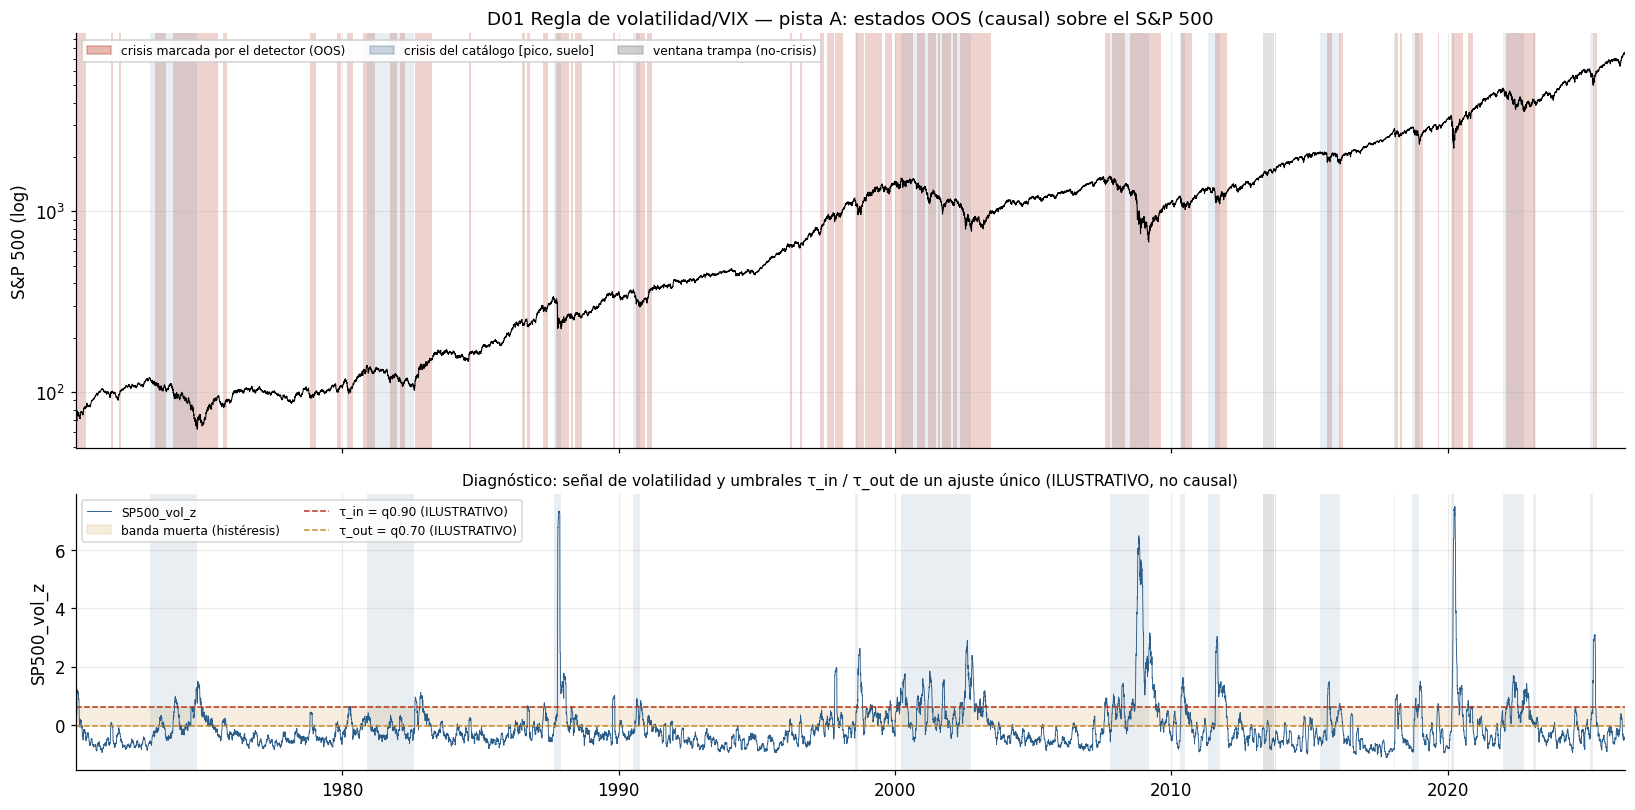

figura -> results/detectores/f1_reglas/D01_B_estados_oos.png


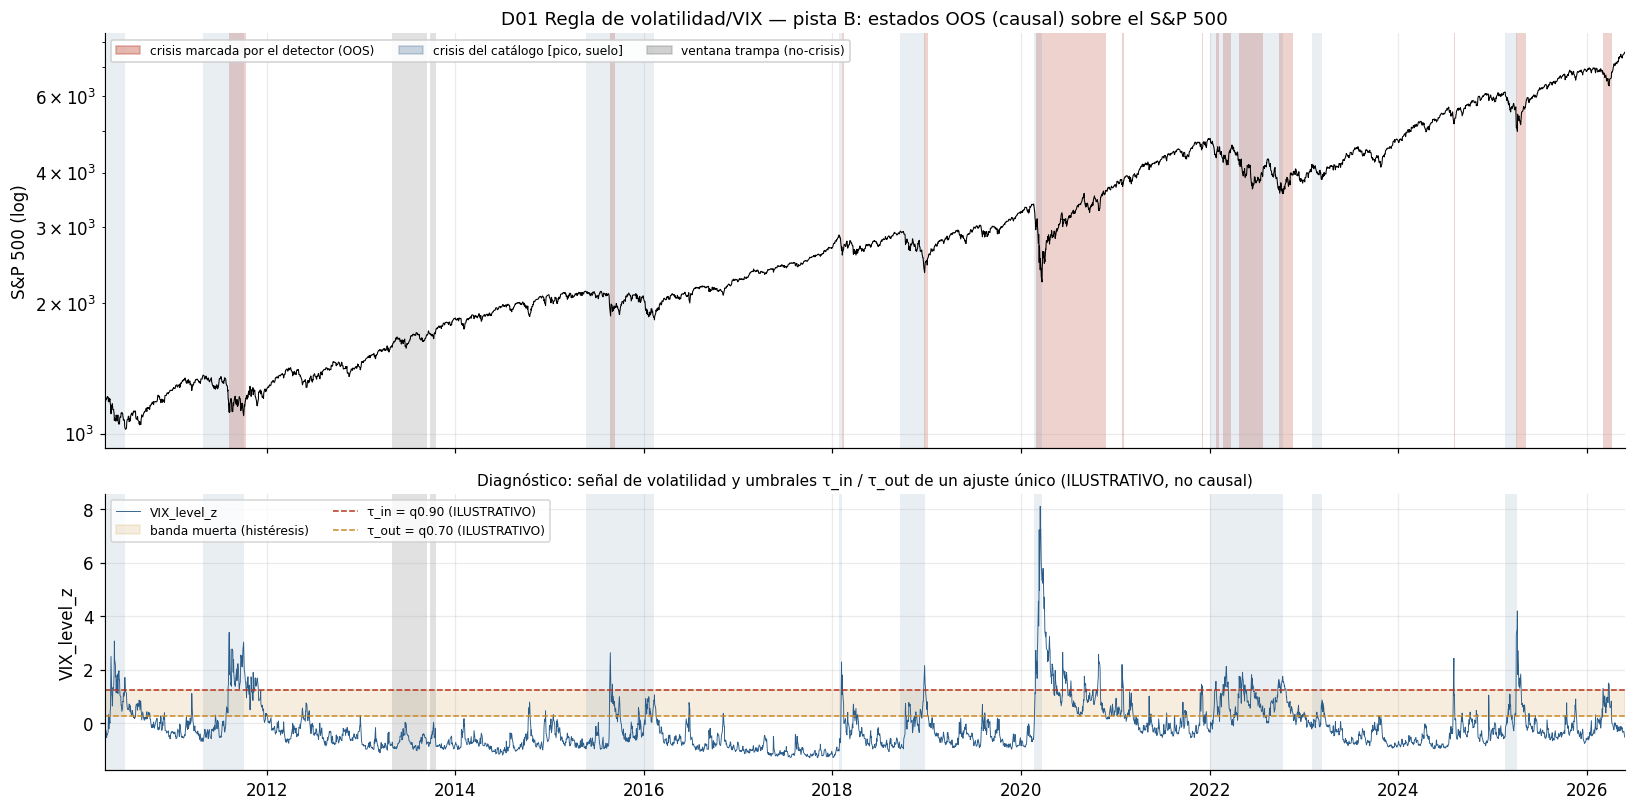

In [7]:
def diag_d01(ax, t, d):
    det, X = ajuste_ilustrativo(t, d)
    oos = PANELES[(t, d)].index
    serie = X[det.feature].reindex(oos)
    ax.plot(serie.index, serie.values, color=viz.C_LONG, lw=0.6, label=det.feature)
    umbrales(ax, det)
    ax.set_ylabel(det.feature)
    ax.legend(loc='upper left', fontsize=8, ncol=2)


figura_detector('D01', diag_d01,
                'Diagnóstico: señal de volatilidad y umbrales τ_in / τ_out de un ajuste único '
                '(ILUSTRATIVO, no causal)')

figura -> results/detectores/f1_reglas/D01_A_cobertura_crisis.png


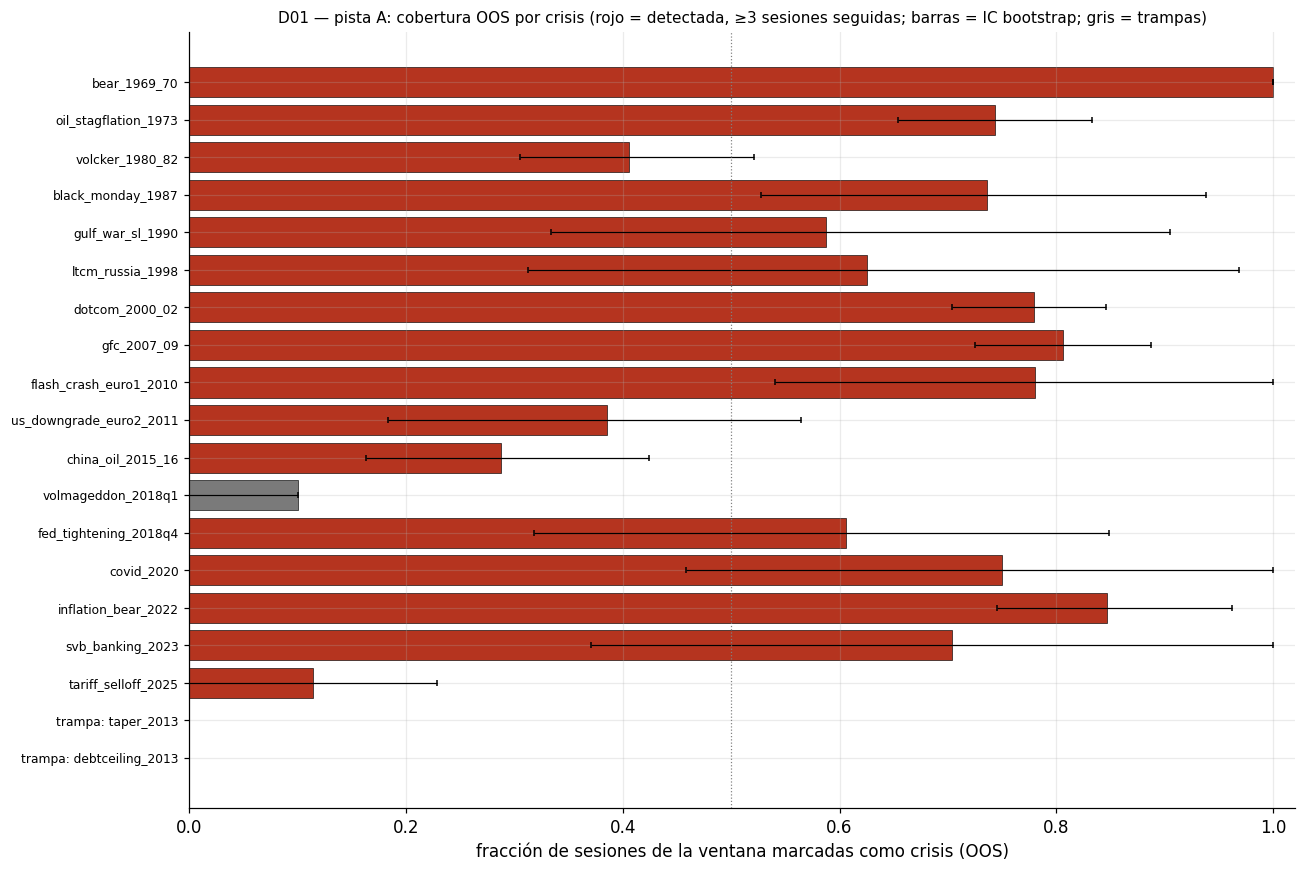

figura -> results/detectores/f1_reglas/D01_B_cobertura_crisis.png


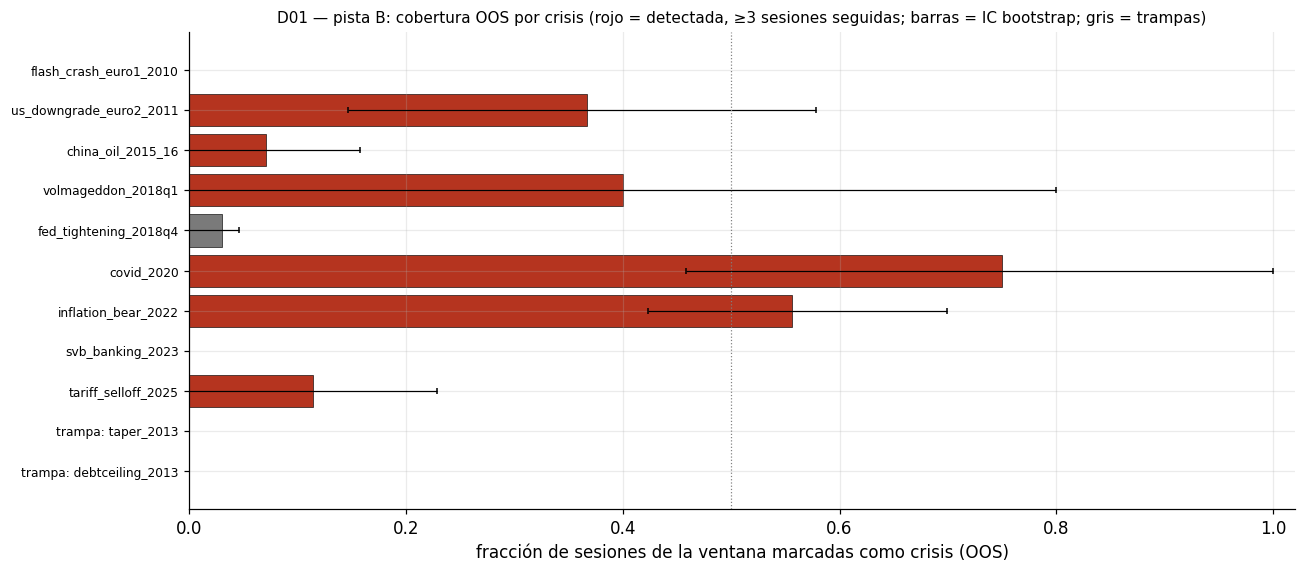

Pista A:


,pico,suelo,cobertura,ic_lo,ic_hi,detectada,lead_lag_dias
crisis,,,,,,,
bear_1969_70,1968-11-29,1970-05-26,1.000,1.000,1.000,1.0,-10.0
oil_stagflation_1973,1973-01-11,1974-10-03,0.744,0.654,0.833,1.0,-221.0
volcker_1980_82,1980-11-28,1982-08-12,0.406,0.305,0.521,1.0,-221.0
black_monday_1987,1987-08-25,1987-12-04,0.736,0.528,0.938,1.0,-168.0
gulf_war_sl_1990,1990-07-16,1990-10-11,0.587,0.333,0.905,1.0,-251.0
ltcm_russia_1998,1998-07-17,1998-08-31,0.625,0.312,0.969,1.0,-252.0
dotcom_2000_02,2000-03-24,2002-10-09,0.779,0.704,0.846,1.0,-252.0
gfc_2007_09,2007-10-09,2009-03-09,0.806,0.725,0.888,1.0,-252.0
flash_crash_euro1_2010,2010-04-23,2010-07-02,0.780,0.540,1.000,1.0,-252.0


Pista B:


,pico,suelo,cobertura,ic_lo,ic_hi,detectada,lead_lag_dias
crisis,,,,,,,
flash_crash_euro1_2010,2010-04-23,2010-07-02,0.000,0.000,0.000,0.0,NaN
us_downgrade_euro2_2011,2011-04-29,2011-10-03,0.367,0.147,0.578,1.0,-39.0
china_oil_2015_16,2015-05-21,2016-02-11,0.071,0.000,0.158,1.0,-118.0
volmageddon_2018q1,2018-01-26,2018-02-08,0.400,0.000,0.800,1.0,-3.0
fed_tightening_2018q4,2018-09-20,2018-12-24,0.030,0.000,0.045,0.0,-223.0
covid_2020,2020-02-19,2020-03-23,0.750,0.458,1.000,1.0,-17.0
inflation_bear_2022,2022-01-03,2022-10-12,0.556,0.423,0.699,1.0,-217.0
svb_banking_2023,2023-02-02,2023-03-13,0.000,0.000,0.000,0.0,-252.0
tariff_selloff_2025,2025-02-19,2025-04-08,0.114,0.000,0.229,1.0,-169.0


In [8]:
TABLAS_COB_D01 = {t: figura_cobertura(t, 'D01') for t in PISTAS}
for t, tab in TABLAS_COB_D01.items():
    print(f'Pista {t}:')
    display(tab.round(3))

In [9]:
display(resumen_ranking(['D01']).round(4))
lectura_detector('D01')

,,puesto_deteccion,de,nivel_etiqueta,score_deteccion,det_event_recall,det_n_detectados,det_n_eventos,det_precision,det_lift_precision,det_base_rate,det_marked_rate,det_mean_crisis_run,mean_crisis_coverage,false_alarm_rate,mean_trap_activation,switching_rate,mean_regime_duration,label_stability,elapsed_seconds
pista,id,,,,,,,,,,,,,,,,,,,
A,D01,2,12,elegible,0.5872,0.9412,16,17,0.4267,2.2001,0.1939,0.2963,79.0189,0.6034,0.5733,0.0,0.0074,133.3302,0.9998,41.7145
B,D01,3,12,elegible,0.5046,0.6667,6,9,0.4060,2.3508,0.1727,0.1153,33.4286,0.2543,0.5940,0.0,0.0069,139.9655,0.9999,5.5607


**D01 — Regla de volatilidad/VIX.**

*Pista A* — puesto **2 de 12** (nivel `elegible`), score = 0.587; detecta 16 de 17 crisis OOS (recall por evento 0.94) con precisión diaria 0.43 (2.20× la tasa base 0.19). Marca crisis el 29.6 % de las sesiones, con episodios de crisis de 79.0 sesiones de media y duración media de régimen 133.3; activación en trampas: `taper_2013` 0 %, `debtceiling_2013` 0 %. Mejor cubierta: `bear_1969_70` (100 %); peor: `volmageddon_2018q1` (10 %). No detectadas: `volmageddon_2018q1`.

*Pista B* — puesto **3 de 12** (nivel `elegible`), score = 0.505; detecta 6 de 9 crisis OOS (recall por evento 0.67) con precisión diaria 0.41 (2.35× la tasa base 0.17). Marca crisis el 11.5 % de las sesiones, con episodios de crisis de 33.4 sesiones de media y duración media de régimen 140.0; activación en trampas: `taper_2013` 0 %, `debtceiling_2013` 0 %. Mejor cubierta: `covid_2020` (75 %); peor: `flash_crash_euro1_2010` (0 %). No detectadas: `flash_crash_euro1_2010`, `fed_tightening_2018q4`, `svb_banking_2023`.

<a id="s4-d02"></a>
### 4.2 D02 — voto compuesto *risk-off*

Diagnóstico: el score compuesto $S_t$ con la banda de histéresis (ajuste único, ILUSTRATIVO). Debajo,
la **descomposición por señal**: media de cada z orientada $\tilde z_{j,t}$ dentro de cada crisis
evaluable (solo sesiones OOS). Responde a *qué canal sostiene el voto en cada episodio* y deja ver la
"grieta" de la curva (señal adelantada que puede restar en plena crisis).

figura -> results/detectores/f1_reglas/D02_A_estados_oos.png


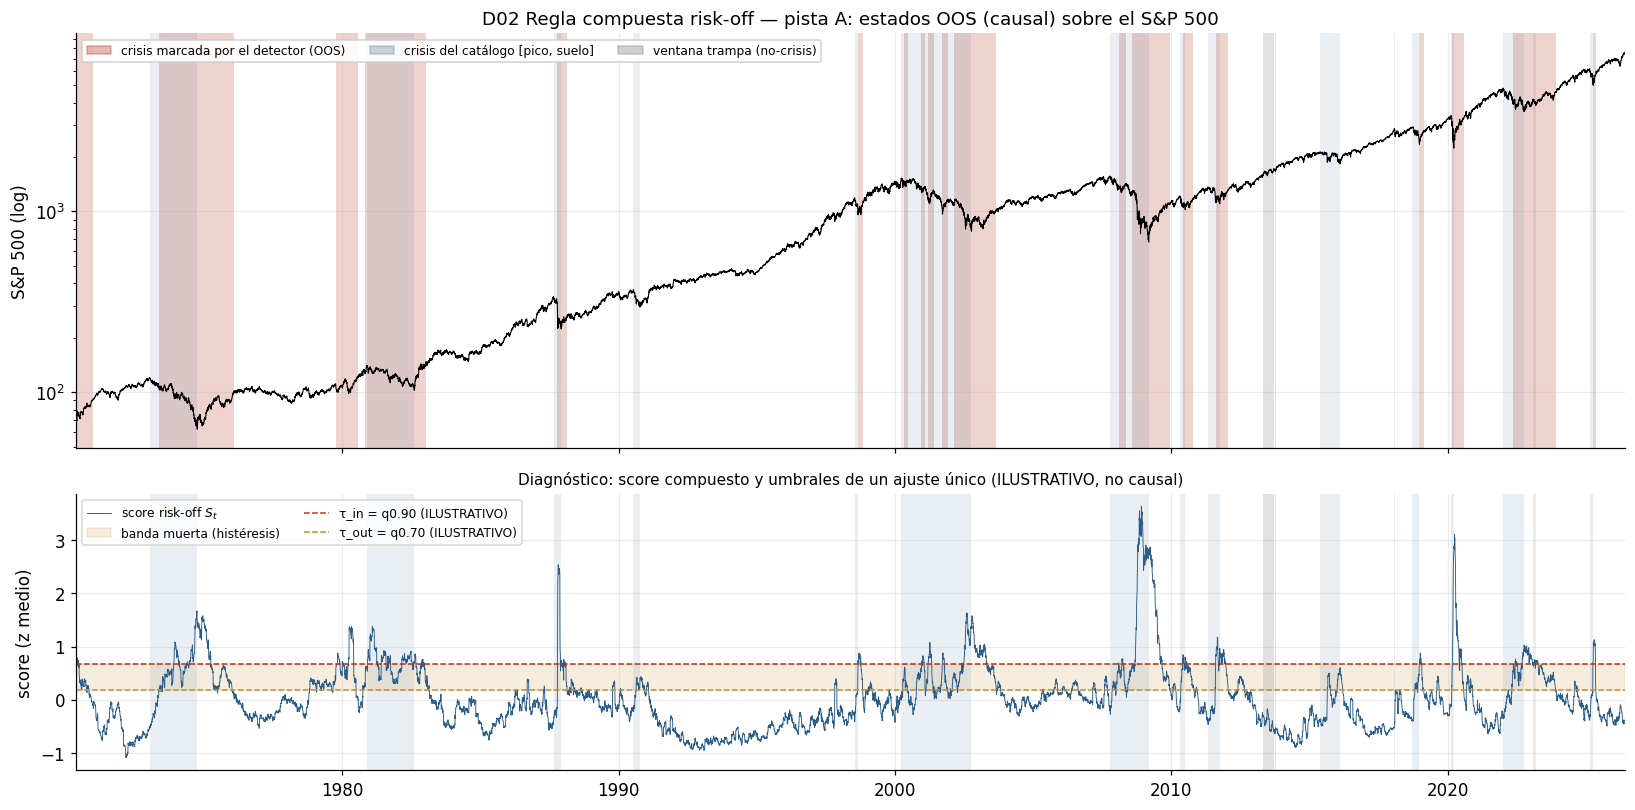

figura -> results/detectores/f1_reglas/D02_B_estados_oos.png


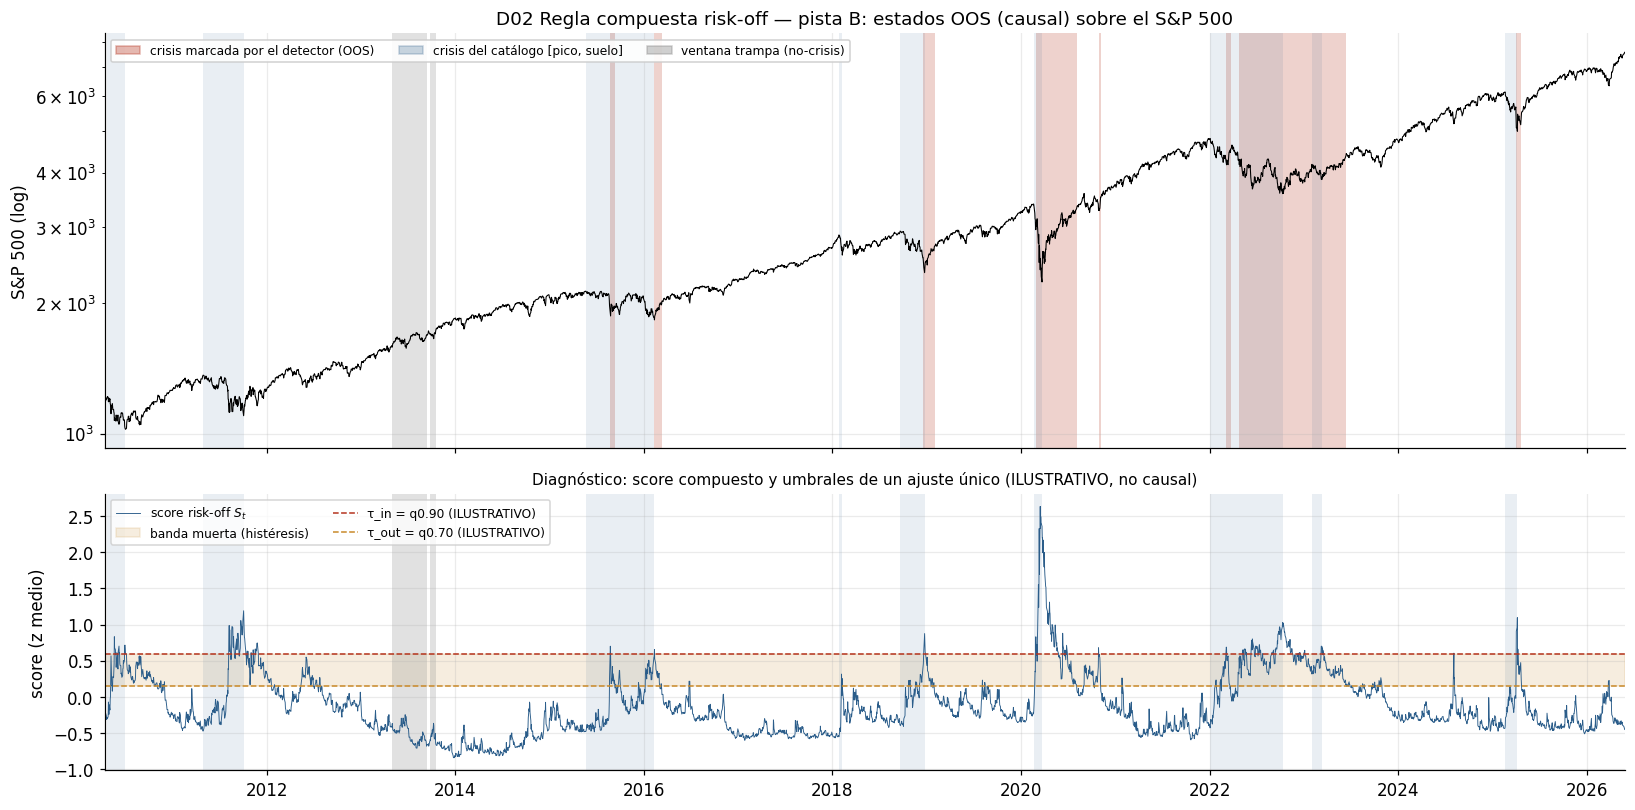

In [10]:
def diag_d02(ax, t, d):
    det, X = ajuste_ilustrativo(t, d)
    oos = PANELES[(t, d)].index
    score = pd.Series(det.composite_score(X), index=X.index).reindex(oos)
    ax.plot(score.index, score.values, color=viz.C_LONG, lw=0.6, label='score risk-off $S_t$')
    umbrales(ax, det)
    ax.set_ylabel('score (z medio)')
    ax.legend(loc='upper left', fontsize=8, ncol=2)


figura_detector('D02', diag_d02,
                'Diagnóstico: score compuesto y umbrales de un ajuste único (ILUSTRATIVO, no causal)')

figura -> results/detectores/f1_reglas/D02_contribucion_por_senal.png


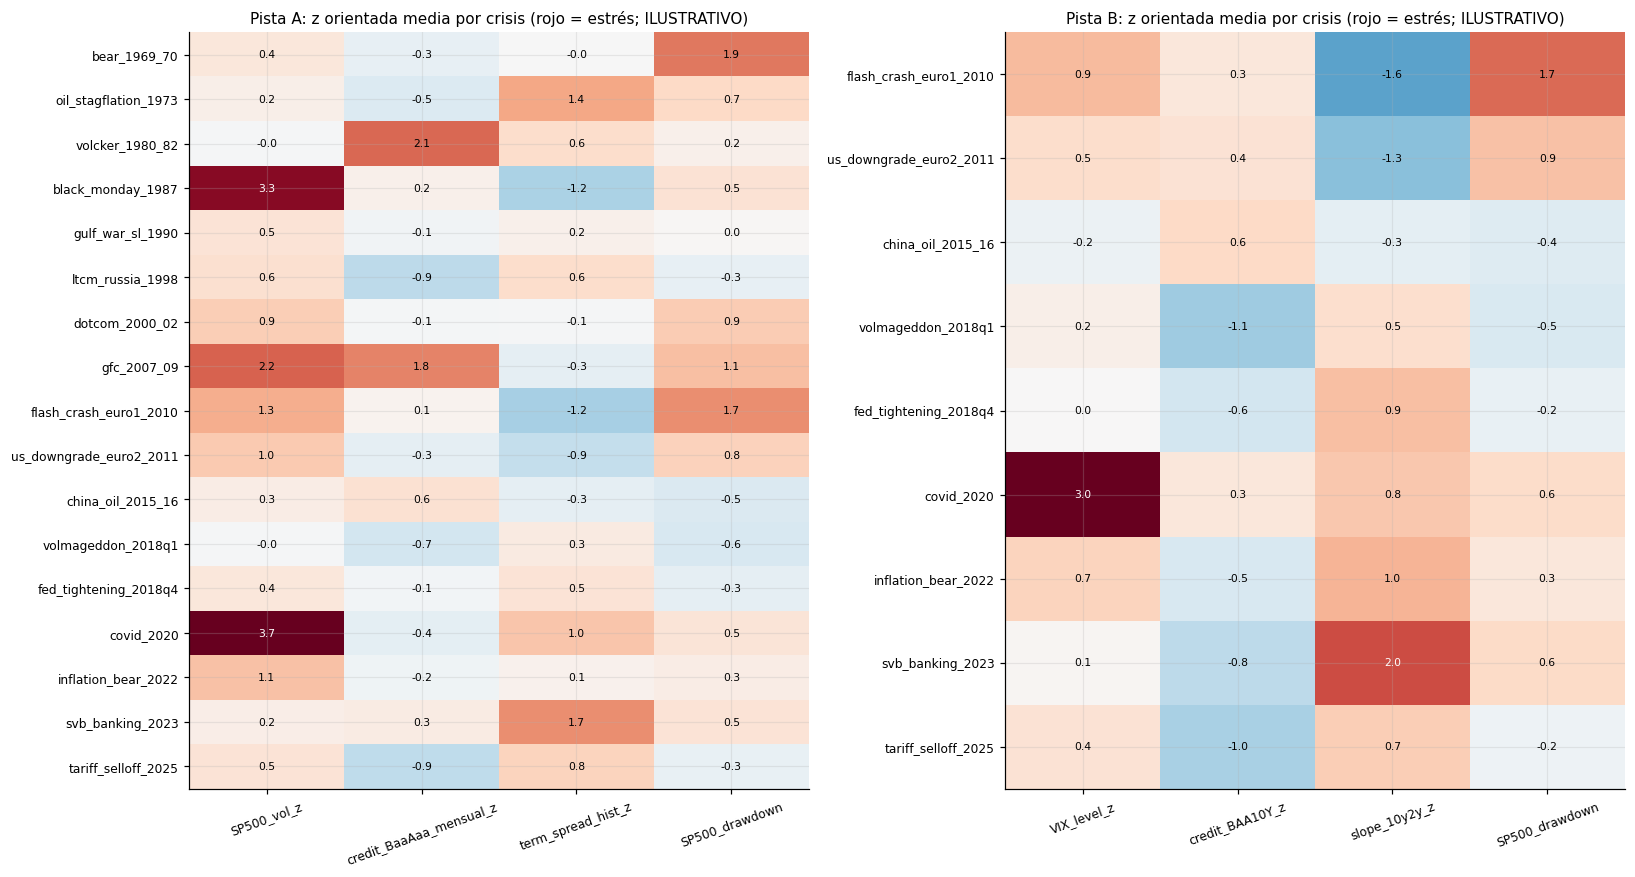

Pista A — señal dominante por crisis: bear_1969_70: SP500_drawdown; oil_stagflation_1973: term_spread_hist_z; volcker_1980_82: credit_BaaAaa_mensual_z; black_monday_1987: SP500_vol_z; gulf_war_sl_1990: SP500_vol_z; ltcm_russia_1998: term_spread_hist_z; dotcom_2000_02: SP500_drawdown; gfc_2007_09: SP500_vol_z; flash_crash_euro1_2010: SP500_drawdown; us_downgrade_euro2_2011: SP500_vol_z; china_oil_2015_16: credit_BaaAaa_mensual_z; volmageddon_2018q1: term_spread_hist_z; fed_tightening_2018q4: term_spread_hist_z; covid_2020: SP500_vol_z; inflation_bear_2022: SP500_vol_z; svb_banking_2023: term_spread_hist_z; tariff_selloff_2025: term_spread_hist_z
Pista A — señales que RESTAN al voto en plena crisis: bear_1969_70: credit_BaaAaa_mensual_z (-0.29); oil_stagflation_1973: credit_BaaAaa_mensual_z (-0.50); volcker_1980_82: SP500_vol_z (-0.05); black_monday_1987: term_spread_hist_z (-1.17); gulf_war_sl_1990: credit_BaaAaa_mensual_z (-0.12); ltcm_russia_1998: credit_BaaAaa_mensual_z (-0.95); dotc

In [11]:
def contribuciones_d02(t):
    det, X = ajuste_ilustrativo(t, 'D02')
    ori = det._oriented(X)
    Z = pd.DataFrame({f: (ori[f] - det._mu[f]) / (det._sigma[f] if det._sigma[f] > 0 else 1.0)
                      for f in det.features}, index=X.index)
    Z = Z.reindex(PANELES[(t, 'D02')].index)
    filas = {c: Z.loc[a:b].mean() for c, (a, b) in CRISIS[t].items() if len(Z.loc[a:b])}
    return pd.DataFrame(filas).T


CONTRIB_D02 = {t: contribuciones_d02(t) for t in PISTAS}
fig, axes = plt.subplots(1, len(PISTAS), figsize=(15, 0.33 * max(len(v) for v in CONTRIB_D02.values()) + 2.5),
                         squeeze=False)
for ax, t in zip(axes[0], PISTAS):
    C = CONTRIB_D02[t]
    lim = np.nanmax(np.abs(C.to_numpy(float)))
    ax.imshow(C.to_numpy(float), cmap='RdBu_r', vmin=-lim, vmax=lim, aspect='auto')
    ax.set_xticks(range(C.shape[1]), C.columns, rotation=20, fontsize=8)
    ax.set_yticks(range(C.shape[0]), C.index, fontsize=8)
    for i in range(C.shape[0]):
        for j in range(C.shape[1]):
            ax.text(j, i, f'{C.iat[i, j]:.1f}', ha='center', va='center', fontsize=7,
                    color='white' if abs(C.iat[i, j]) > 0.6 * lim else 'black')
    ax.set_title(f'Pista {t}: z orientada media por crisis (rojo = estrés; ILUSTRATIVO)', fontsize=10)
fig.tight_layout()
guardar(fig, 'D02_contribucion_por_senal')
plt.show()
for t in PISTAS:
    dom = CONTRIB_D02[t].idxmax(axis=1)
    resta = CONTRIB_D02[t].idxmin(axis=1)
    print(f'Pista {t} — señal dominante por crisis: ' + '; '.join(f'{c}: {dom[c]}' for c in dom.index))
    negativas = [(c, resta[c], CONTRIB_D02[t].loc[c, resta[c]]) for c in resta.index
                 if CONTRIB_D02[t].loc[c, resta[c]] < 0]
    print(f'Pista {t} — señales que RESTAN al voto en plena crisis: '
          + ('; '.join(f'{c}: {f} ({v:+.2f})' for c, f, v in negativas) or 'ninguna'))

figura -> results/detectores/f1_reglas/D02_A_cobertura_crisis.png


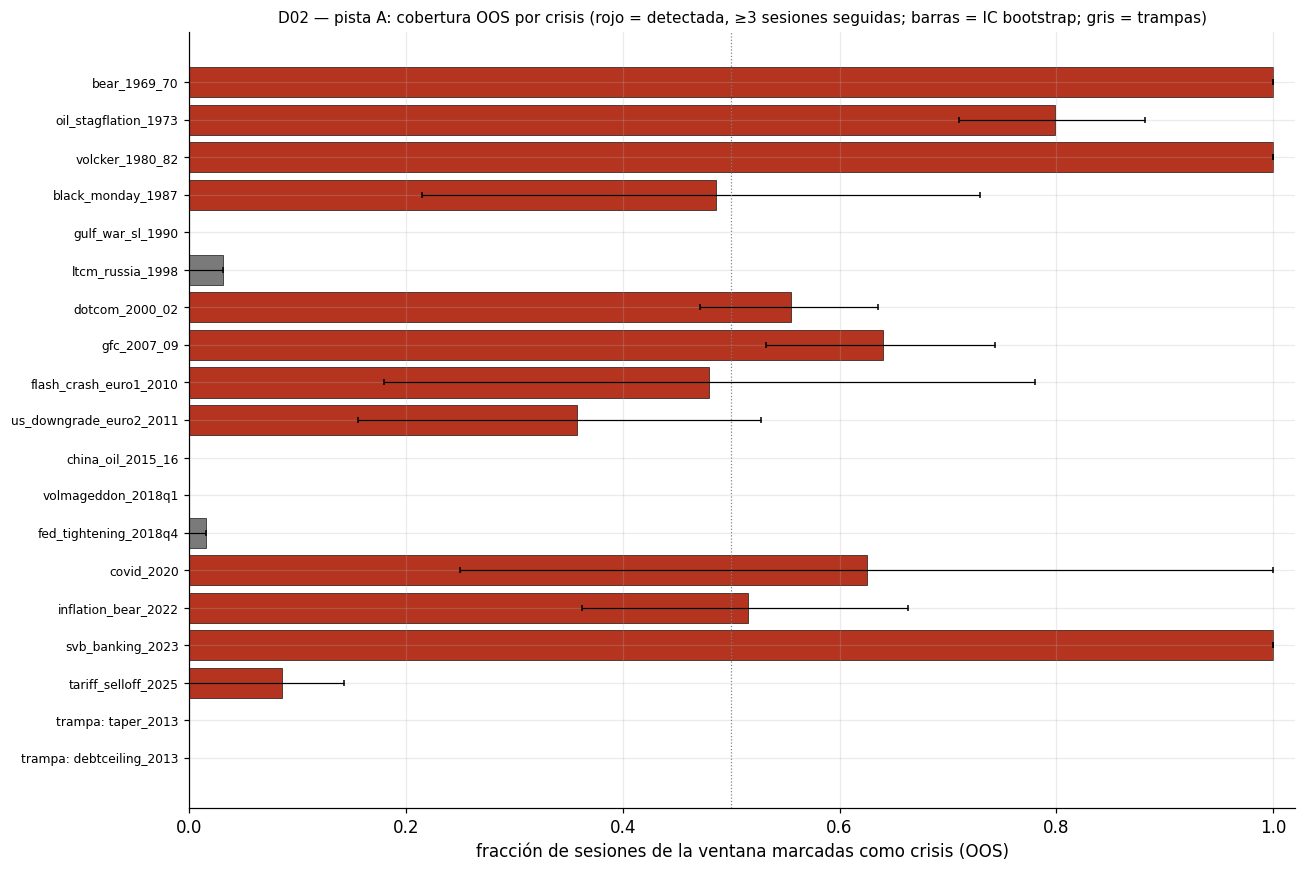

figura -> results/detectores/f1_reglas/D02_B_cobertura_crisis.png


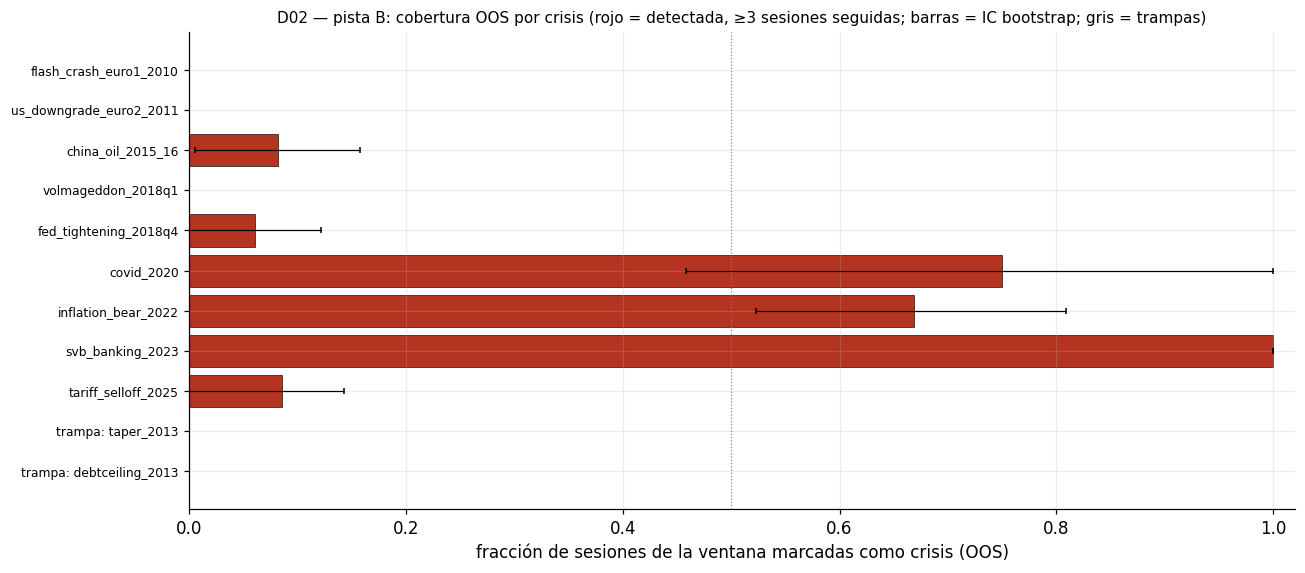

Pista A:


,pico,suelo,cobertura,ic_lo,ic_hi,detectada,lead_lag_dias
crisis,,,,,,,
bear_1969_70,1968-11-29,1970-05-26,1.000,1.000,1.000,1.0,-10.0
oil_stagflation_1973,1973-01-11,1974-10-03,0.799,0.710,0.882,1.0,-252.0
volcker_1980_82,1980-11-28,1982-08-12,1.000,1.000,1.000,1.0,-252.0
black_monday_1987,1987-08-25,1987-12-04,0.486,0.215,0.730,1.0,-34.0
gulf_war_sl_1990,1990-07-16,1990-10-11,0.000,0.000,0.000,0.0,NaN
ltcm_russia_1998,1998-07-17,1998-08-31,0.031,0.000,0.031,0.0,NaN
dotcom_2000_02,2000-03-24,2002-10-09,0.555,0.471,0.636,1.0,-252.0
gfc_2007_09,2007-10-09,2009-03-09,0.640,0.532,0.743,1.0,-252.0
flash_crash_euro1_2010,2010-04-23,2010-07-02,0.480,0.180,0.780,1.0,-252.0


Pista B:


,pico,suelo,cobertura,ic_lo,ic_hi,detectada,lead_lag_dias
crisis,,,,,,,
flash_crash_euro1_2010,2010-04-23,2010-07-02,0.000,0.000,0.000,0.0,NaN
us_downgrade_euro2_2011,2011-04-29,2011-10-03,0.000,0.000,0.000,0.0,NaN
china_oil_2015_16,2015-05-21,2016-02-11,0.082,0.005,0.158,1.0,-118.0
volmageddon_2018q1,2018-01-26,2018-02-08,0.000,0.000,0.000,0.0,NaN
fed_tightening_2018q4,2018-09-20,2018-12-24,0.061,0.000,0.121,1.0,-3.0
covid_2020,2020-02-19,2020-03-23,0.750,0.458,1.000,1.0,-17.0
inflation_bear_2022,2022-01-03,2022-10-12,0.668,0.523,0.809,1.0,-152.0
svb_banking_2023,2023-02-02,2023-03-13,1.000,1.000,1.000,1.0,-252.0
tariff_selloff_2025,2025-02-19,2025-04-08,0.086,0.000,0.143,1.0,-2.0


In [12]:
TABLAS_COB_D02 = {t: figura_cobertura(t, 'D02') for t in PISTAS}
for t, tab in TABLAS_COB_D02.items():
    print(f'Pista {t}:')
    display(tab.round(3))

In [13]:
display(resumen_ranking(['D02']).round(4))
lectura_detector('D02')

,,puesto_deteccion,de,nivel_etiqueta,score_deteccion,det_event_recall,det_n_detectados,det_n_eventos,det_precision,det_lift_precision,det_base_rate,det_marked_rate,det_mean_crisis_run,mean_crisis_coverage,false_alarm_rate,mean_trap_activation,switching_rate,mean_regime_duration,label_stability,elapsed_seconds
pista,id,,,,,,,,,,,,,,,,,,,
A,D02,4,12,elegible,0.5588,0.7059,12,17,0.4624,2.3844,0.1939,0.2477,184.2632,0.4465,0.5376,0.0,0.0026,371.9211,0.9984,26.5957
B,D02,4,12,elegible,0.5013,0.6667,6,9,0.4016,2.3255,0.1727,0.1215,61.6250,0.2940,0.5984,0.0,0.0039,238.7647,0.9984,4.2406


**D02 — Regla compuesta risk-off.**

*Pista A* — puesto **4 de 12** (nivel `elegible`), score = 0.559; detecta 12 de 17 crisis OOS (recall por evento 0.71) con precisión diaria 0.46 (2.38× la tasa base 0.19). Marca crisis el 24.8 % de las sesiones, con episodios de crisis de 184.3 sesiones de media y duración media de régimen 371.9; activación en trampas: `taper_2013` 0 %, `debtceiling_2013` 0 %. Mejor cubierta: `bear_1969_70` (100 %); peor: `gulf_war_sl_1990` (0 %). No detectadas: `gulf_war_sl_1990`, `ltcm_russia_1998`, `china_oil_2015_16`, `volmageddon_2018q1`, `fed_tightening_2018q4`.

*Pista B* — puesto **4 de 12** (nivel `elegible`), score = 0.501; detecta 6 de 9 crisis OOS (recall por evento 0.67) con precisión diaria 0.40 (2.33× la tasa base 0.17). Marca crisis el 12.1 % de las sesiones, con episodios de crisis de 61.6 sesiones de media y duración media de régimen 238.8; activación en trampas: `taper_2013` 0 %, `debtceiling_2013` 0 %. Mejor cubierta: `svb_banking_2023` (100 %); peor: `flash_crash_euro1_2010` (0 %). No detectadas: `flash_crash_euro1_2010`, `us_downgrade_euro2_2011`, `volmageddon_2018q1`.

<a id="s4-d10"></a>
### 4.3 D10 — turbulencia de Mahalanobis

Diagnóstico: la distancia $d_t$ en escala logarítmica con la banda de histéresis. La serie $d_t$ se
recomputa con la covarianza **expanding causal** (cada día usa solo el pasado), pero los umbrales
son los de un ajuste único sobre toda la pista (ILUSTRATIVO). Debajo se contrasta $d_t$ con la
volatilidad realizada a 21 sesiones del S&P 500: si la correlación de rangos fuese ≈ 1, la
turbulencia no aportaría nada multivariante sobre una regla de volatilidad (D01).

figura -> results/detectores/f1_reglas/D10_A_estados_oos.png


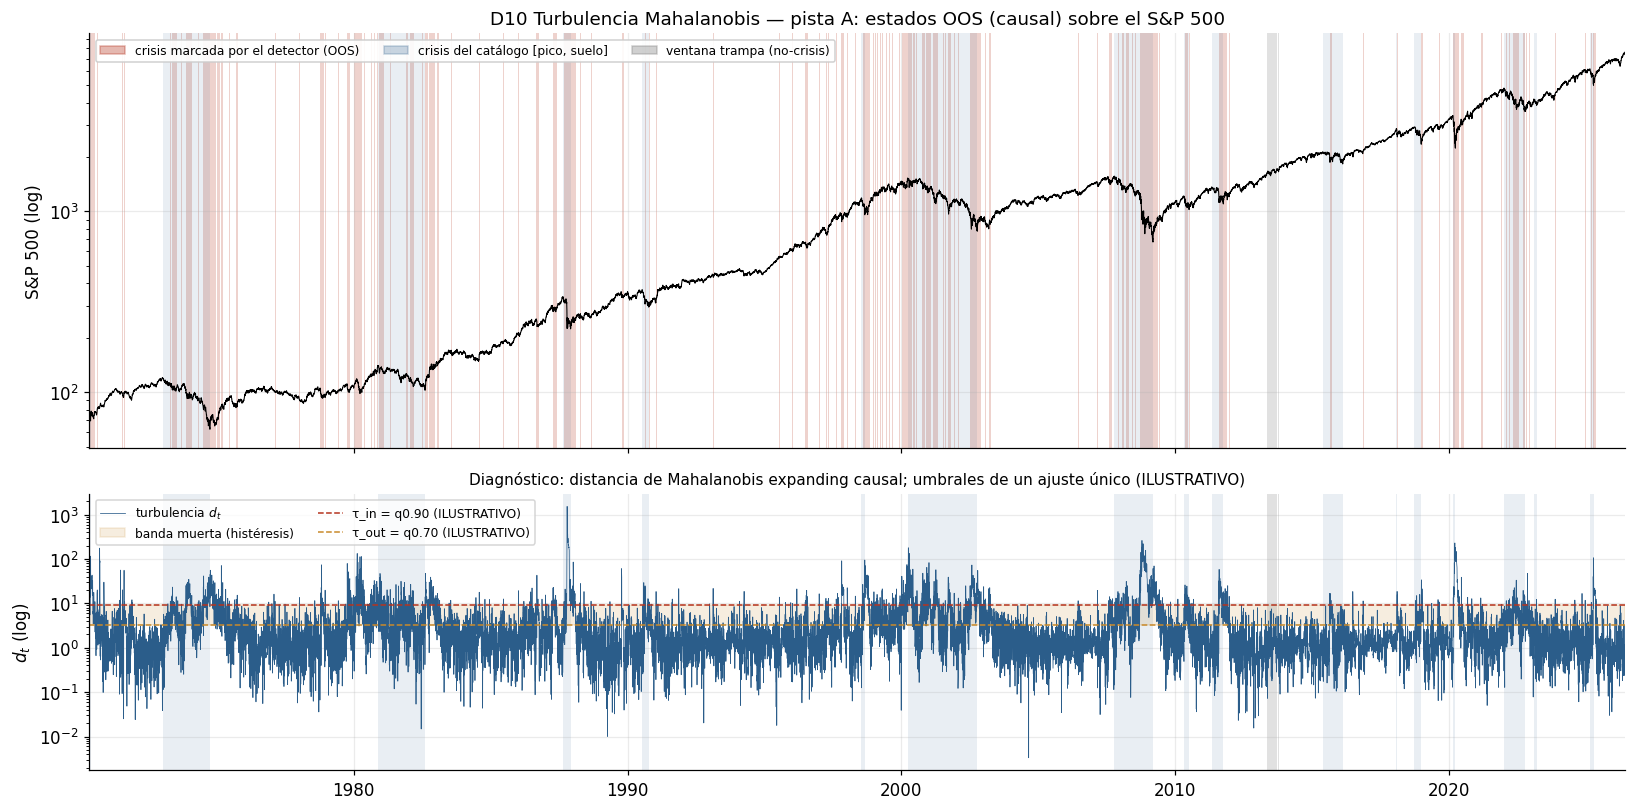

figura -> results/detectores/f1_reglas/D10_B_estados_oos.png


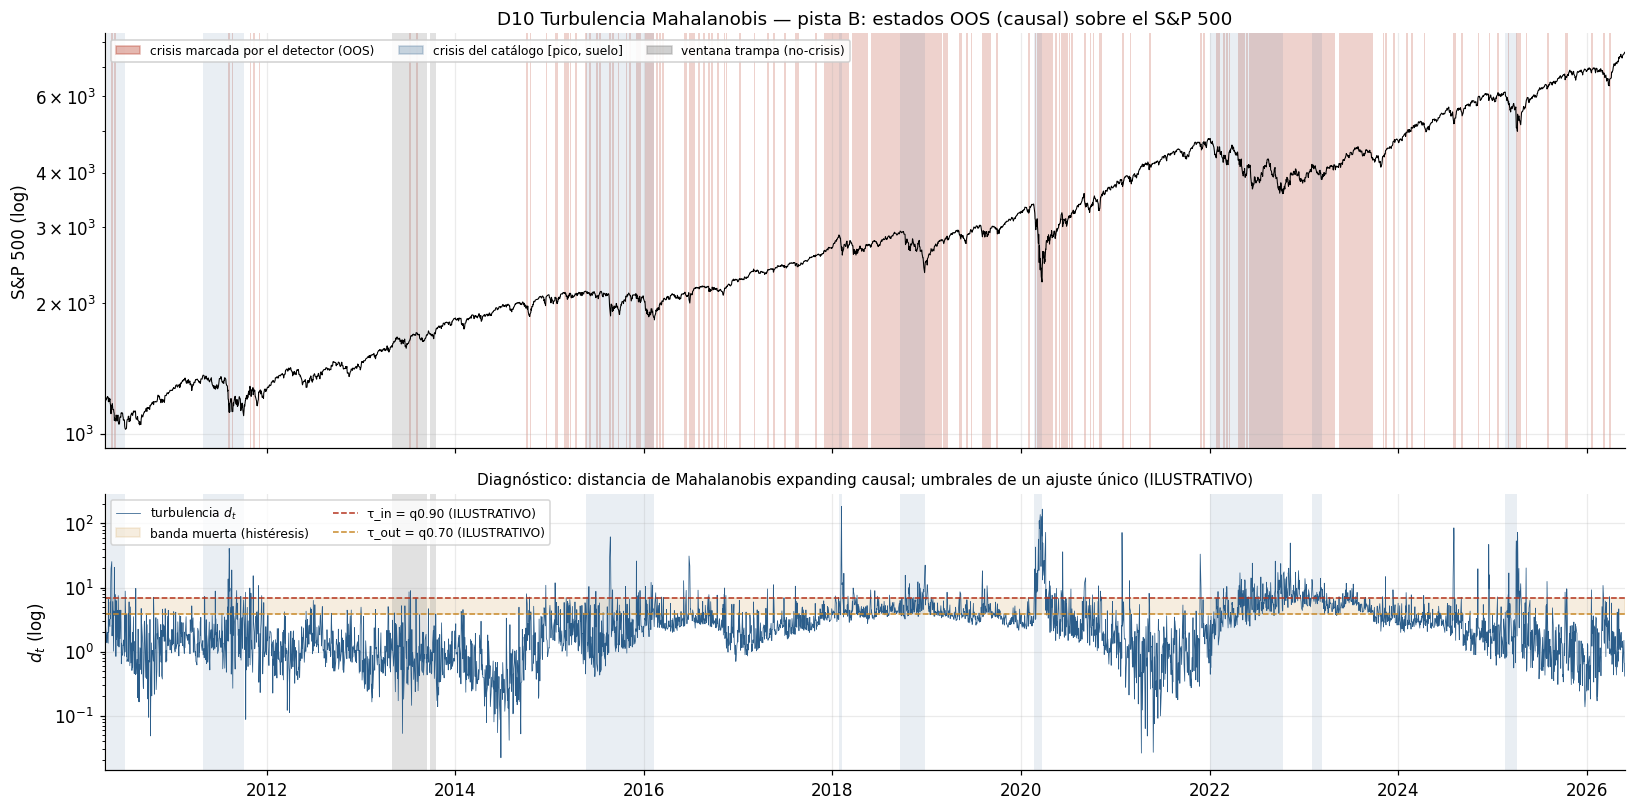

In [14]:
TURB = {}


def turbulencia(t):
    if t not in TURB:
        det, X = ajuste_ilustrativo(t, 'D10')
        TURB[t] = det.turbulence(X)
    return TURB[t]


def diag_d10(ax, t, d):
    det, _ = ajuste_ilustrativo(t, d)
    serie = turbulencia(t).reindex(PANELES[(t, d)].index)
    ax.plot(serie.index, serie.values, color=viz.C_LONG, lw=0.5, label='turbulencia $d_t$')
    umbrales(ax, det)
    ax.set_yscale('log')
    ax.set_ylabel('$d_t$ (log)')
    ax.legend(loc='upper left', fontsize=8, ncol=2)


figura_detector('D10', diag_d10,
                'Diagnóstico: distancia de Mahalanobis expanding causal; umbrales de un ajuste único (ILUSTRATIVO)')

Pista A: correlación de rangos turbulencia–volatilidad realizada = 0.522 (rho² = 0.272: fracción de la varianza de los rangos de d_t explicada linealmente por los rangos de la volatilidad; el resto, 0.728, es información que la volatilidad univariante no ordena)
Pista B: correlación de rangos turbulencia–volatilidad realizada = 0.261 (rho² = 0.068: fracción de la varianza de los rangos de d_t explicada linealmente por los rangos de la volatilidad; el resto, 0.932, es información que la volatilidad univariante no ordena)


figura -> results/detectores/f1_reglas/D10_turbulencia_vs_volatilidad.png


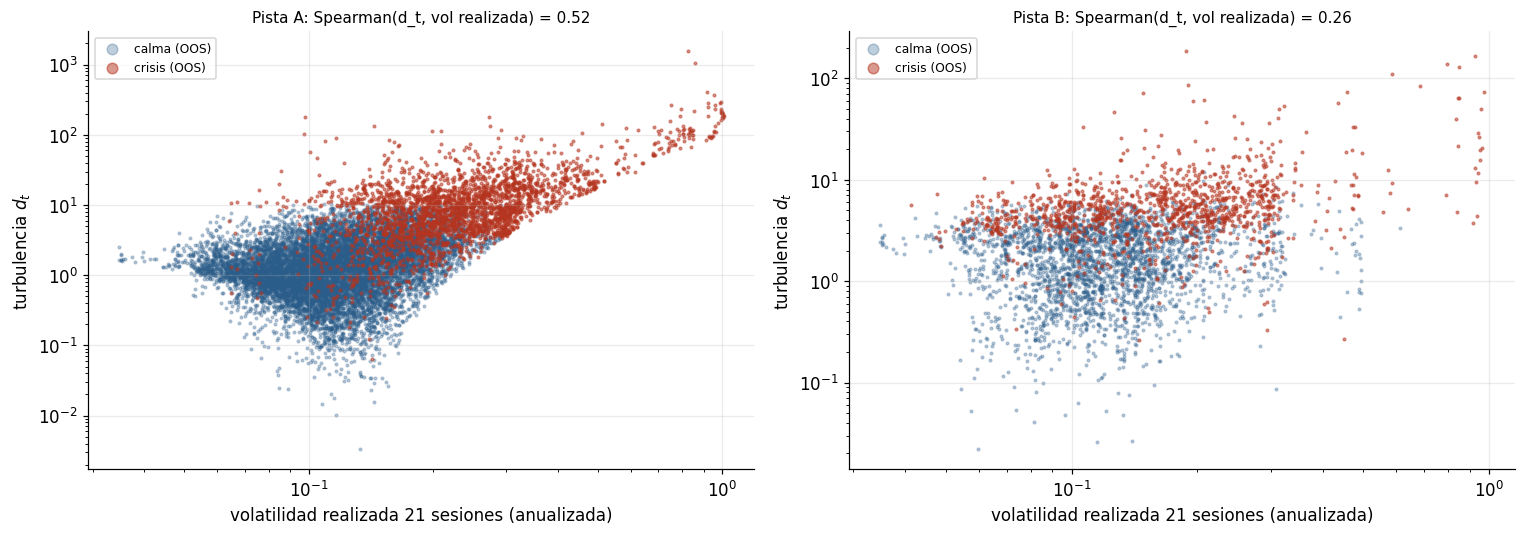

In [15]:
fig, axes = plt.subplots(1, len(PISTAS), figsize=(14, 5), squeeze=False)
for ax, t in zip(axes[0], PISTAS):
    oos = PANELES[(t, 'D10')].index
    d_t = turbulencia(t).reindex(oos)
    rv = DATOS[t]['SP500_ret'].rolling(21).std().mul(np.sqrt(252)).reindex(oos)
    ok = d_t.notna() & rv.notna()
    rho = d_t[ok].corr(rv[ok], method='spearman')
    crisis = es_crisis(t, 'D10')[ok]
    ax.scatter(rv[ok][~crisis], d_t[ok][~crisis], s=3, alpha=0.3, color=viz.C_LONG, label='calma (OOS)')
    ax.scatter(rv[ok][crisis], d_t[ok][crisis], s=3, alpha=0.5, color=viz.C_CRISIS, label='crisis (OOS)')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('volatilidad realizada 21 sesiones (anualizada)')
    ax.set_ylabel('turbulencia $d_t$')
    ax.set_title(f'Pista {t}: Spearman(d_t, vol realizada) = {rho:.2f}', fontsize=10)
    ax.legend(fontsize=8, markerscale=4)
    print(f'Pista {t}: correlación de rangos turbulencia–volatilidad realizada = {rho:.3f} '
          f'(rho² = {rho ** 2:.3f}: fracción de la varianza de los rangos de d_t explicada linealmente por '
          f'los rangos de la volatilidad; el resto, {1 - rho ** 2:.3f}, es información que la volatilidad '
          f'univariante no ordena)')
fig.tight_layout()
guardar(fig, 'D10_turbulencia_vs_volatilidad')
plt.show()

figura -> results/detectores/f1_reglas/D10_A_cobertura_crisis.png


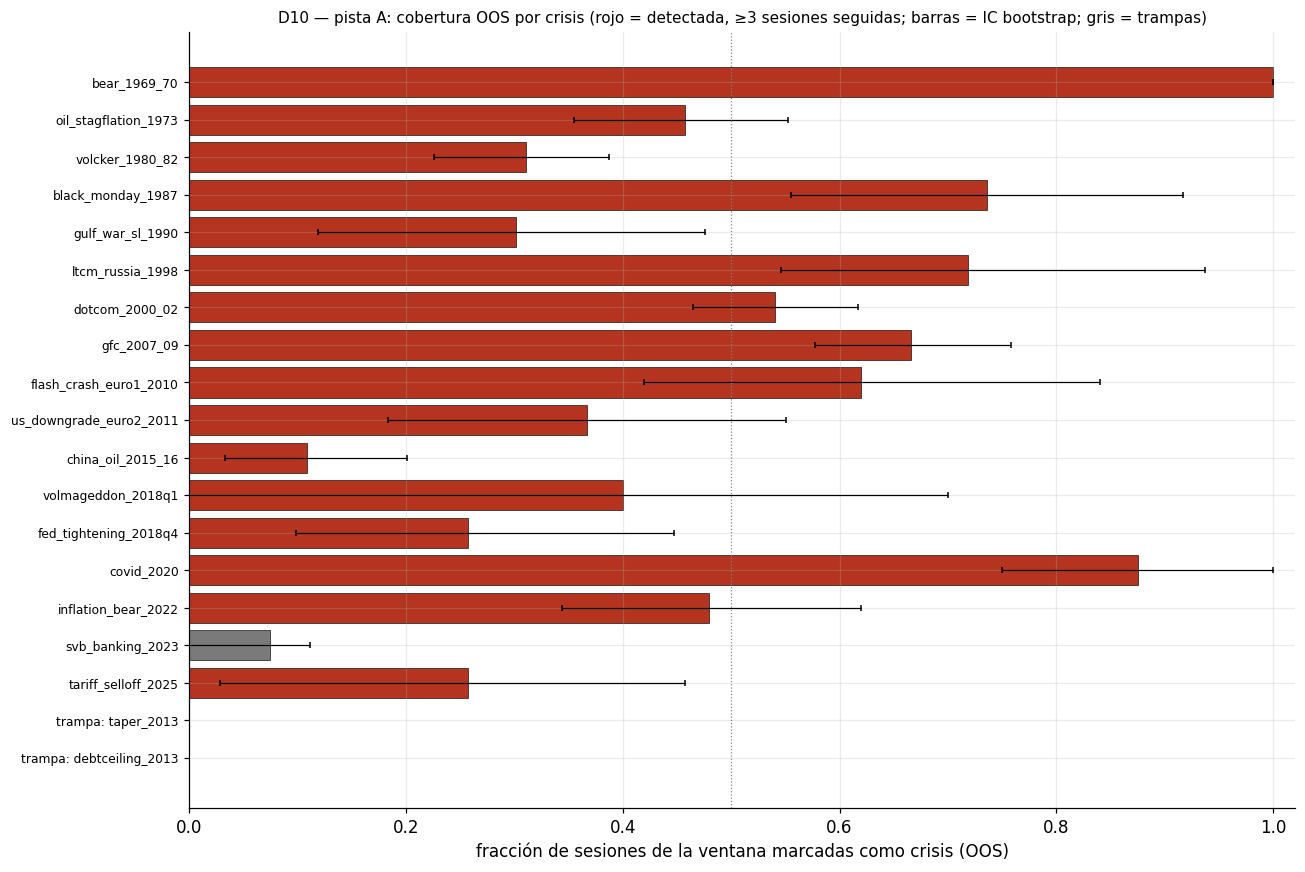

figura -> results/detectores/f1_reglas/D10_B_cobertura_crisis.png


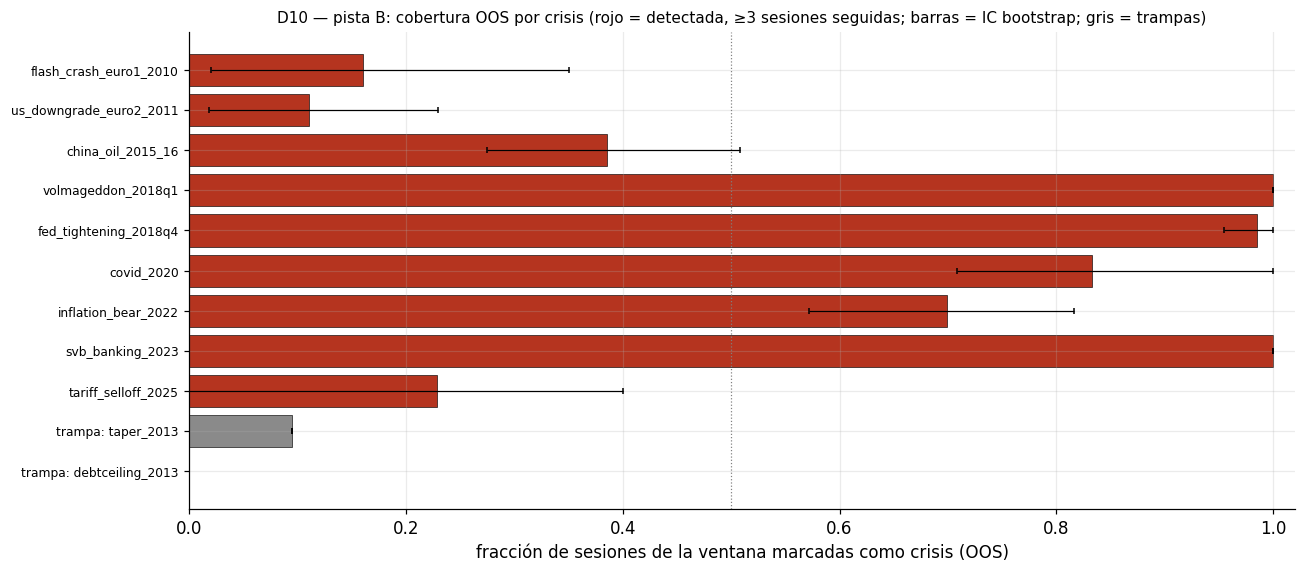

Pista A:


,pico,suelo,cobertura,ic_lo,ic_hi,detectada,lead_lag_dias
crisis,,,,,,,
bear_1969_70,1968-11-29,1970-05-26,1.000,1.000,1.000,1.0,-9.0
oil_stagflation_1973,1973-01-11,1974-10-03,0.458,0.355,0.553,1.0,-212.0
volcker_1980_82,1980-11-28,1982-08-12,0.311,0.226,0.387,1.0,-222.0
black_monday_1987,1987-08-25,1987-12-04,0.736,0.556,0.917,1.0,-164.0
gulf_war_sl_1990,1990-07-16,1990-10-11,0.302,0.119,0.476,1.0,NaN
ltcm_russia_1998,1998-07-17,1998-08-31,0.719,0.546,0.938,1.0,-212.0
dotcom_2000_02,2000-03-24,2002-10-09,0.541,0.465,0.617,1.0,-58.0
gfc_2007_09,2007-10-09,2009-03-09,0.666,0.577,0.758,1.0,-245.0
flash_crash_euro1_2010,2010-04-23,2010-07-02,0.620,0.420,0.840,1.0,NaN


Pista B:


,pico,suelo,cobertura,ic_lo,ic_hi,detectada,lead_lag_dias
crisis,,,,,,,
flash_crash_euro1_2010,2010-04-23,2010-07-02,0.160,0.020,0.350,1.0,NaN
us_downgrade_euro2_2011,2011-04-29,2011-10-03,0.110,0.018,0.229,1.0,NaN
china_oil_2015_16,2015-05-21,2016-02-11,0.386,0.274,0.508,1.0,-120.0
volmageddon_2018q1,2018-01-26,2018-02-08,1.000,1.000,1.000,1.0,-18.0
fed_tightening_2018q4,2018-09-20,2018-12-24,0.985,0.955,1.000,1.0,-238.0
covid_2020,2020-02-19,2020-03-23,0.833,0.708,1.000,1.0,-154.0
inflation_bear_2022,2022-01-03,2022-10-12,0.699,0.571,0.816,1.0,-152.0
svb_banking_2023,2023-02-02,2023-03-13,1.000,1.000,1.000,1.0,-215.0
tariff_selloff_2025,2025-02-19,2025-04-08,0.229,0.000,0.400,1.0,-170.0


In [16]:
TABLAS_COB_D10 = {t: figura_cobertura(t, 'D10') for t in PISTAS}
for t, tab in TABLAS_COB_D10.items():
    print(f'Pista {t}:')
    display(tab.round(3))

In [17]:
display(resumen_ranking(['D10']).round(4))
lectura_detector('D10')

,,puesto_deteccion,de,nivel_etiqueta,score_deteccion,det_event_recall,det_n_detectados,det_n_eventos,det_precision,det_lift_precision,det_base_rate,det_marked_rate,det_mean_crisis_run,mean_crisis_coverage,false_alarm_rate,mean_trap_activation,switching_rate,mean_regime_duration,label_stability,elapsed_seconds
pista,id,,,,,,,,,,,,,,,,,,,
A,D10,1,12,elegible,0.6136,0.9412,16,17,0.4552,2.3471,0.1939,0.1959,9.3831,0.4806,0.5448,0.0000,0.0417,23.9542,0.9991,2612.3032
B,D10,6,12,elegible,0.4569,1.0000,9,9,0.2961,1.7146,0.1727,0.2979,10.5130,0.6002,0.7039,0.0474,0.0567,17.5714,0.9958,291.4481


**D10 — Turbulencia Mahalanobis.**

*Pista A* — puesto **1 de 12** (nivel `elegible`), score = 0.614; detecta 16 de 17 crisis OOS (recall por evento 0.94) con precisión diaria 0.46 (2.35× la tasa base 0.19). Marca crisis el 19.6 % de las sesiones, con episodios de crisis de 9.4 sesiones de media y duración media de régimen 24.0; activación en trampas: `taper_2013` 0 %, `debtceiling_2013` 0 %. Mejor cubierta: `bear_1969_70` (100 %); peor: `svb_banking_2023` (7 %). No detectadas: `svb_banking_2023`.

*Pista B* — puesto **6 de 12** (nivel `elegible`), score = 0.457; detecta 9 de 9 crisis OOS (recall por evento 1.00) con precisión diaria 0.30 (1.71× la tasa base 0.17). Marca crisis el 29.8 % de las sesiones, con episodios de crisis de 10.5 sesiones de media y duración media de régimen 17.6; activación en trampas: `taper_2013` 9 %, `debtceiling_2013` 0 %. Mejor cubierta: `volmageddon_2018q1` (100 %); peor: `us_downgrade_euro2_2011` (11 %). Detecta todas las crisis evaluables.

<a id="s4-sep"></a>
### 4.4 Separación de la señal por régimen OOS (las tres reglas)

Si la señal de cribado discrimina, su distribución condicionada al estado OOS debe estar desplazada:
masa baja y compacta en calma, cola alta en crisis. El solape entre ambas es exactamente la zona
donde un umbral simple parpadearía y donde actúa la banda muerta. Las señales son las del ajuste
ILUSTRATIVO (misma recomputación que en §4.1–4.3); los estados son los OOS causales.

figura -> results/detectores/f1_reglas/F1_separacion_senal_por_regimen.png


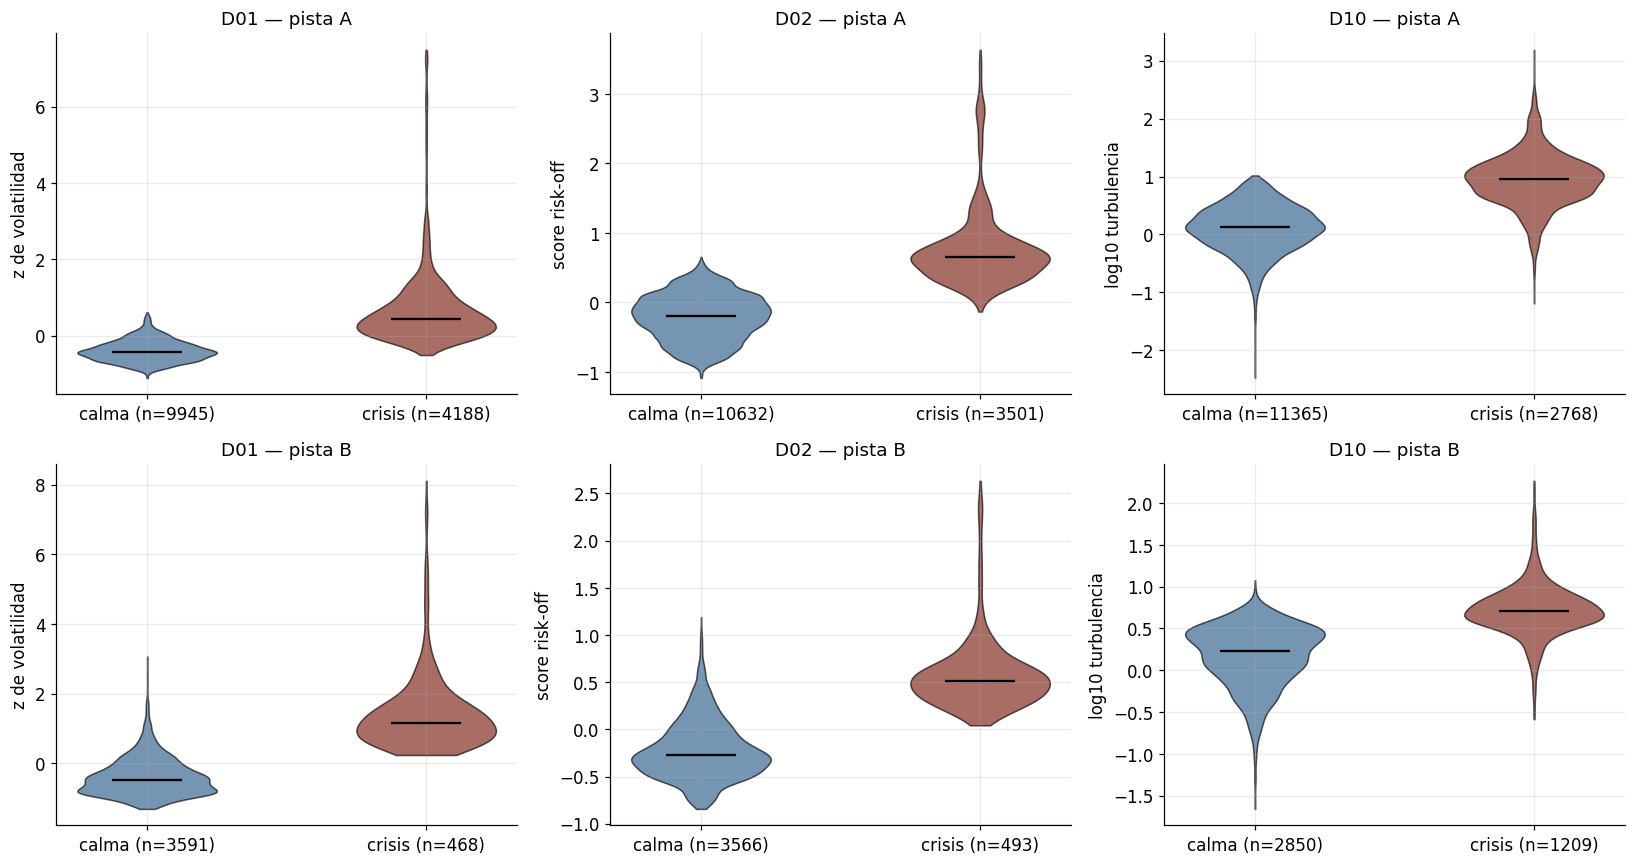

mediana_calma  mediana_crisis
pista id                                
A     D01         -0.423           0.438
      D02         -0.191           0.648
      D10          0.124           0.959
B     D01         -0.471           1.166
      D02         -0.272           0.513
      D10          0.230           0.706

In [18]:
def senal(t, d):
    det, X = ajuste_ilustrativo(t, d)
    if d == 'D01':
        s = X[det.feature]
    elif d == 'D02':
        s = pd.Series(det.composite_score(X), index=X.index)
    else:
        s = np.log10(turbulencia(t))
    return s.reindex(PANELES[(t, d)].index)


NOMBRE_SENAL = {'D01': 'z de volatilidad', 'D02': 'score risk-off', 'D10': 'log10 turbulencia'}
fig, axes = plt.subplots(len(PISTAS), len(DETECTORES), figsize=(15, 8), squeeze=False)
filas = []
for i, t in enumerate(PISTAS):
    for j, d in enumerate(DETECTORES):
        s = senal(t, d)
        st = PANELES[(t, d)]['state'].astype(int)
        ok = s.notna() & np.isfinite(s)
        viz.plot_distribution_by_regime(s[ok], st[ok], crisis_state=estado_crisis(t, d),
                                        labels={0: 'calma', estado_crisis(t, d): 'crisis'}, kind='violin',
                                        ax=axes[i][j], title=f'{d} — pista {t}', xlabel=NOMBRE_SENAL[d])
        med = s[ok].groupby(st[ok]).median()
        filas.append({'pista': t, 'id': d, 'mediana_calma': med.get(0, np.nan),
                      'mediana_crisis': med.get(estado_crisis(t, d), np.nan)})
fig.tight_layout()
guardar(fig, 'F1_separacion_senal_por_regimen')
plt.show()
display(pd.DataFrame(filas).set_index(['pista', 'id']).round(3))

<a id="s5"></a>
## 5. Comparación intra-familia

Tres lecturas: (i) la tabla del ranking ADR-003 de los tres detectores en las dos pistas y su
posición en el plano *recall por evento × precisión diaria* de todo el banco (curvas punteadas =
iso-score); (ii) cuánto se **solapan** los días que marcan en crisis (índice de Jaccard: 1 = marcan
exactamente los mismos días) y (iii) el mapa de cobertura crisis × detector, que muestra qué
episodios ve cada regla y cuáles se escapan a toda la familia.

,,puesto_deteccion,de,nivel_etiqueta,score_deteccion,det_event_recall,det_n_detectados,det_n_eventos,det_precision,det_lift_precision,det_base_rate,det_marked_rate,det_mean_crisis_run,mean_crisis_coverage,false_alarm_rate,mean_trap_activation,switching_rate,mean_regime_duration,label_stability,elapsed_seconds
pista,id,,,,,,,,,,,,,,,,,,,
A,D01,2,12,elegible,0.5872,0.9412,16,17,0.4267,2.2001,0.1939,0.2963,79.0189,0.6034,0.5733,0.0000,0.0074,133.3302,0.9998,41.7145
B,D01,3,12,elegible,0.5046,0.6667,6,9,0.4060,2.3508,0.1727,0.1153,33.4286,0.2543,0.5940,0.0000,0.0069,139.9655,0.9999,5.5607
A,D02,4,12,elegible,0.5588,0.7059,12,17,0.4624,2.3844,0.1939,0.2477,184.2632,0.4465,0.5376,0.0000,0.0026,371.9211,0.9984,26.5957
B,D02,4,12,elegible,0.5013,0.6667,6,9,0.4016,2.3255,0.1727,0.1215,61.6250,0.2940,0.5984,0.0000,0.0039,238.7647,0.9984,4.2406
A,D10,1,12,elegible,0.6136,0.9412,16,17,0.4552,2.3471,0.1939,0.1959,9.3831,0.4806,0.5448,0.0000,0.0417,23.9542,0.9991,2612.3032
B,D10,6,12,elegible,0.4569,1.0000,9,9,0.2961,1.7146,0.1727,0.2979,10.5130,0.6002,0.7039,0.0474,0.0567,17.5714,0.9958,291.4481


figura -> results/detectores/f1_reglas/F1_comparativa_recall_precision.png


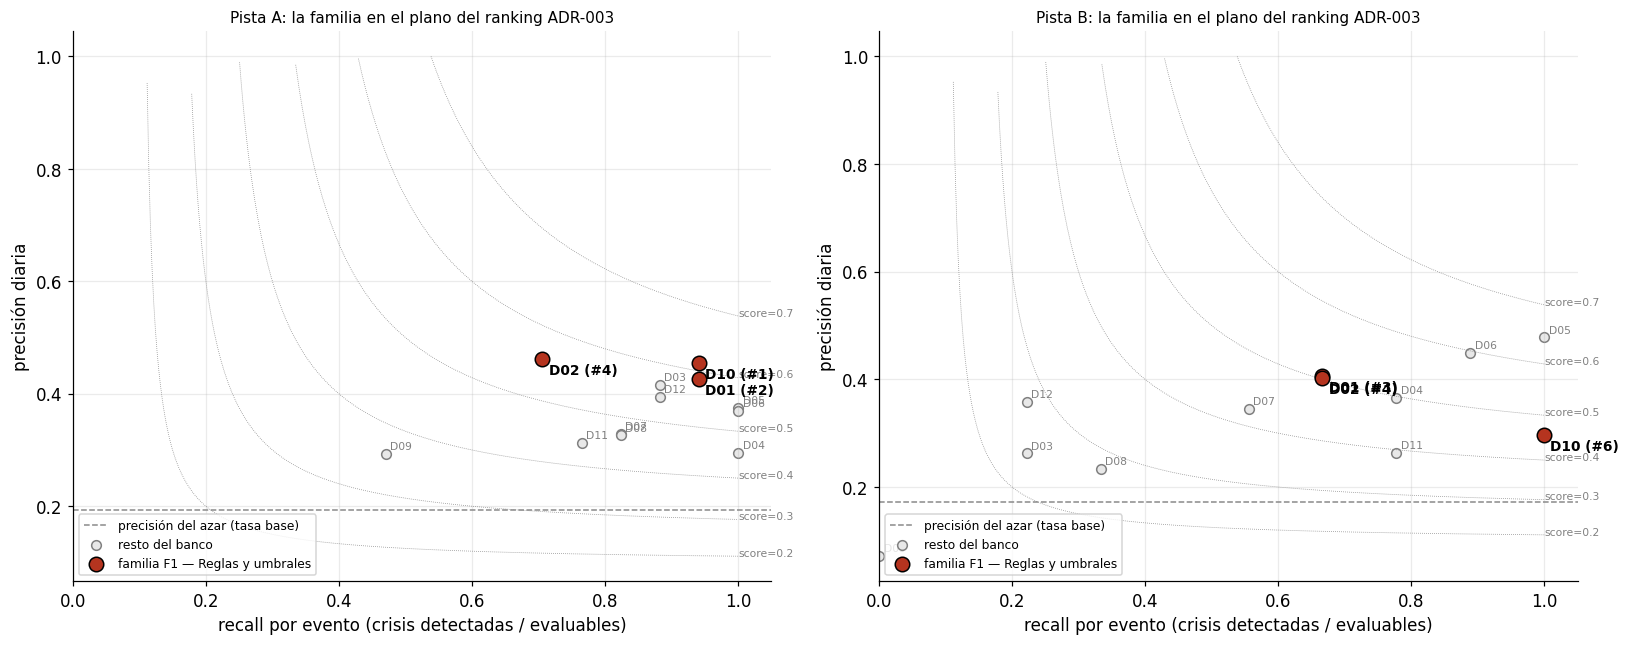

In [19]:
display(resumen_ranking(DETECTORES).round(4))

# Plano recall por evento vs precisión diaria de TODO el banco, con la familia resaltada.
fig, axes = plt.subplots(1, len(PISTAS), figsize=(15, 6), squeeze=False)
for ax, t in zip(axes[0], PISTAS):
    inf.dibujar_plano_ranking(ax, RANKING[RANKING['pista'] == t], DETECTORES, beta=BETA,
                              etiqueta=f'familia {NOMBRE_FAMILIA}',
                              titulo=f'Pista {t}: la familia en el plano del ranking ADR-003')
fig.tight_layout()
guardar(fig, 'F1_comparativa_recall_precision')
plt.show()

figura -> results/detectores/f1_reglas/F1_comparativa_coincidencia_cobertura.png


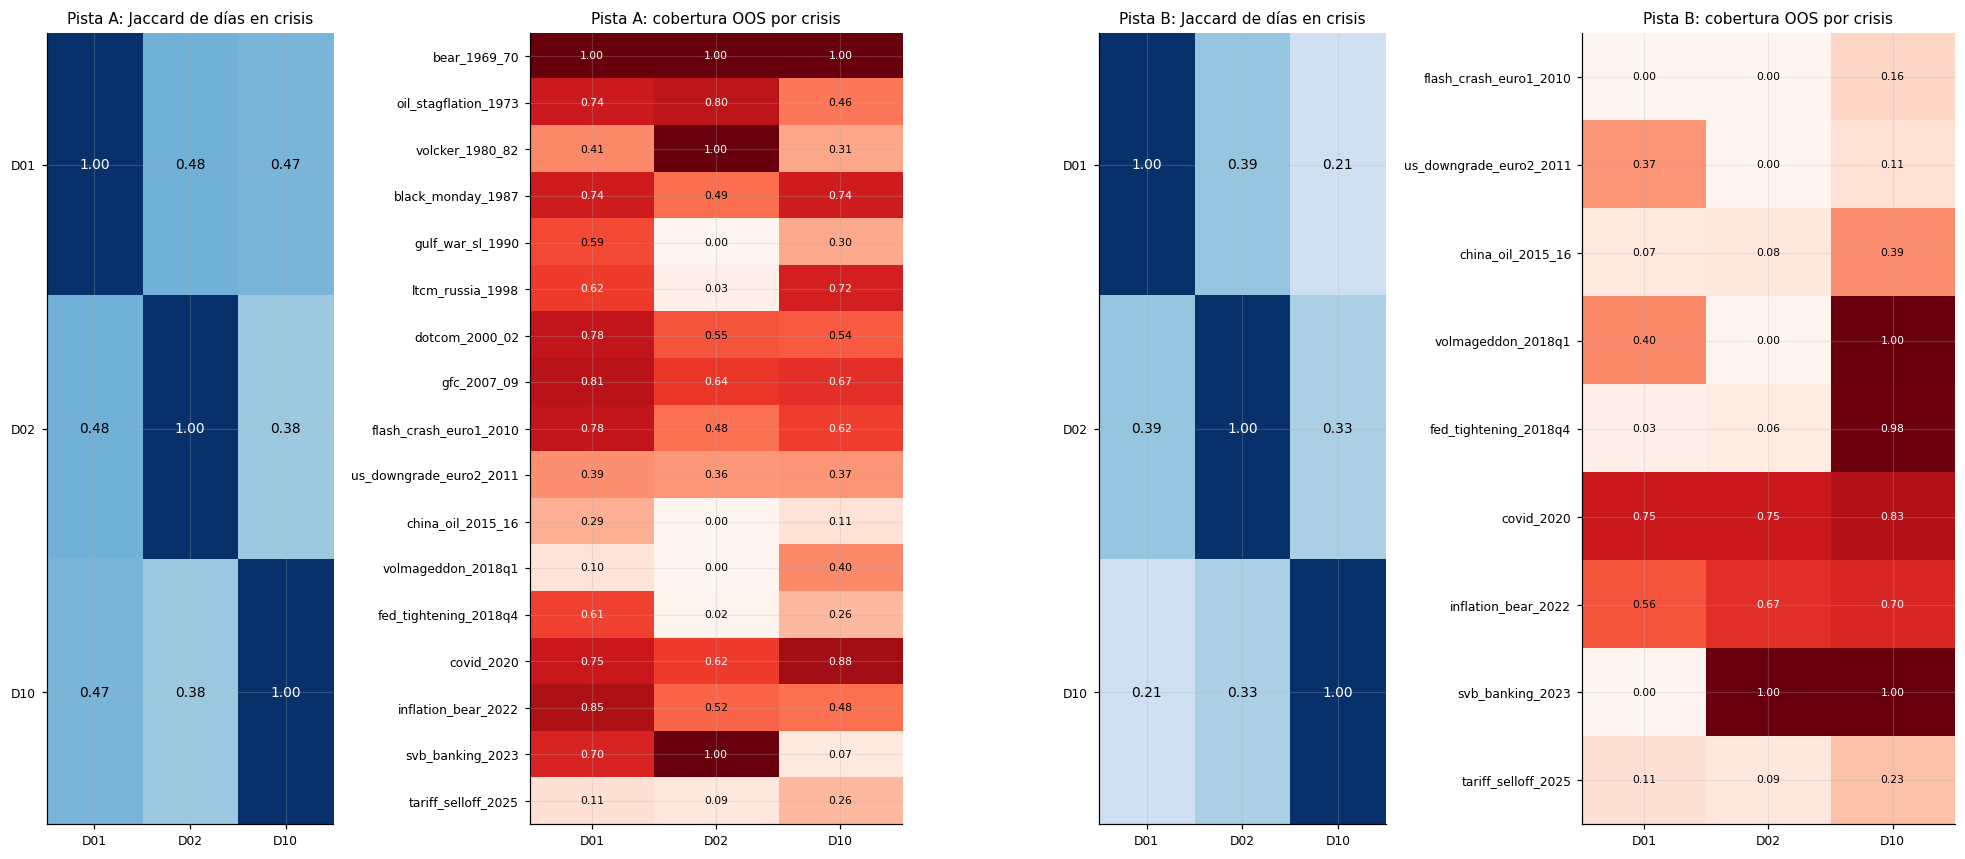

Pista A — índice de Jaccard entre los días marcados crisis:


,D01,D02,D10
D01,1.000,0.481,0.468
D02,0.481,1.000,0.376
D10,0.468,0.376,1.000


Pista B — índice de Jaccard entre los días marcados crisis:


,D01,D02,D10
D01,1.000,0.395,0.209
D02,0.395,1.000,0.333
D10,0.209,0.333,1.000


In [20]:
def coincidencia(t):
    return inf.matriz_jaccard({d: es_crisis(t, d) for d in DETECTORES})


def matriz_cobertura(t):
    return pd.DataFrame({d: tabla_cobertura(t, d)['cobertura'] for d in DETECTORES})


COINC = {t: coincidencia(t) for t in PISTAS}
COB = {t: matriz_cobertura(t) for t in PISTAS}
fig, axes = plt.subplots(1, 2 * len(PISTAS), figsize=(18, 0.32 * max(len(c) for c in COB.values()) + 2.5),
                         gridspec_kw={'width_ratios': [1, 1.3] * len(PISTAS)}, squeeze=False)
for i, t in enumerate(PISTAS):
    inf.dibujar_heatmap(axes[0][2 * i], COINC[t], cmap='Blues', fontsize=9,
                        titulo=f'Pista {t}: Jaccard de días en crisis')
    inf.dibujar_heatmap(axes[0][2 * i + 1], COB[t], cmap='Reds',
                        titulo=f'Pista {t}: cobertura OOS por crisis')
fig.tight_layout()
guardar(fig, 'F1_comparativa_coincidencia_cobertura')
plt.show()
for t in PISTAS:
    print(f'Pista {t} — índice de Jaccard entre los días marcados crisis:')
    display(COINC[t].round(3))

In [21]:
# Persistencia: la histéresis es común, pero la señal decide cuánto parpadea cada regla.
pers = METRICAS[['switching_rate', 'mean_regime_duration', 'det_mean_crisis_run', 'det_marked_rate']].copy()
display(pers.round(4))

switching_rate  mean_regime_duration  det_mean_crisis_run  det_marked_rate
pista id                                                                             
A     D01          0.0074              133.3302              79.0189           0.2963
      D02          0.0026              371.9211             184.2632           0.2477
      D10          0.0417               23.9542               9.3831           0.1959
B     D01          0.0069              139.9655              33.4286           0.1153
      D02          0.0039              238.7647              61.6250           0.1215
      D10          0.0567               17.5714              10.5130           0.2979

In [22]:
lineas = []
for t in PISTAS:
    r = RANK.loc[[(t, d) for d in DETECTORES]].sort_values('puesto_deteccion')
    mejor = r.index[0][1]
    J = COINC[t].where(~np.eye(len(DETECTORES), dtype=bool))
    a, b = J.stack().idxmax()
    cob = COB[t]
    comun = cob.index[(cob > 0.5).all(axis=1)].tolist()
    ninguno = cob.index[(cob < 0.1).all(axis=1)].tolist()
    lineas.append(
        f'- **Pista {t}**: orden intra-familia '
        + ' > '.join(f"{d} (#{int(RANK.loc[(t, d), 'puesto_deteccion'])})" for _, d in r.index)
        + f'; el mejor de la familia es **{mejor}** con score {RANK.loc[(t, mejor), "score_deteccion"]:.3f}. '
        f'Par más redundante: {a}–{b} (Jaccard {J.loc[a, b]:.2f}). '
        f'Crisis cubiertas >50 % por todos: {", ".join(comun) or "ninguna"}; '
        f'crisis que ninguno cubre >10 %: {", ".join(ninguno) or "ninguna"}.')
display(Markdown('\n'.join(lineas)))

- **Pista A**: orden intra-familia D10 (#1) > D01 (#2) > D02 (#4); el mejor de la familia es **D10** con score 0.614. Par más redundante: D01–D02 (Jaccard 0.48). Crisis cubiertas >50 % por todos: bear_1969_70, dotcom_2000_02, gfc_2007_09, covid_2020; crisis que ninguno cubre >10 %: ninguna.
- **Pista B**: orden intra-familia D01 (#3) > D02 (#4) > D10 (#6); el mejor de la familia es **D01** con score 0.505. Par más redundante: D01–D02 (Jaccard 0.39). Crisis cubiertas >50 % por todos: covid_2020, inflation_bear_2022; crisis que ninguno cubre >10 %: ninguna.

<a id="s6"></a>
## 6. Hallazgos de la Capa 1 (v1) y qué se mantiene o cambia en v2

**Lo que concluyó la Capa 1** (notebooks congelados en el tag git `capa1-final`:
`capa1-final:capa1_exploracion/notebooks/01_rule_vix_threshold.ipynb`, `02_rule_composite_riskoff.ipynb`
y `10_turbulence_mahalanobis.ipynb`, p. ej. `git show capa1-final:capa1_exploracion/notebooks/01_rule_vix_threshold.ipynb`;
cifras v1 en `docs/historia/capa1/resultados/`; fichas `docs/detectores/D01_*.md`, `D02_*.md`, `D10_*.md`; cifras en la celda siguiente; hipótesis del CHECKPOINT 2 y su veredicto en §6.1):

- **D01** era el *baseline de miedo limpio y persistente*: con la histéresis no se disparaba de forma
  sostenida en las trampas (taper 2013, venta de Q4-2018), cubría bien las crisis con pico de
  volatilidad (GFC, COVID) y **infra-detectaba el bear lento de 2022** (tipos, VIX moderado). Su tasa
  global de falsas alarmas era alta, pero inflada por ventanas de crisis estrechas y estrés real no
  catalogado (LTCM, puntocom, 2015-16, SVB). Lección de núcleo: con una única feature que no es un
  retorno, el etiquetado económico podía **invertir** calma/crisis; se resolvió pasando el retorno del
  S&P 500 (hoy `market_returns` en cada fold).
- **D02** mejoraba 2022 frente a D01 al sumar crédito y drawdown al miedo, a cambio de **más
  falsas alarmas** (Q4-2018), más conmutaciones y episodios más cortos; 2008 y 2011 no eran
  evaluables OOS (el crédito HYG empezaba en 2007). La **sensibilidad a los pesos** quedó confirmada:
  la curva se empinó en 2008/2011 y restaba score en plena crisis.
- **D10** captaba los eventos sistémicos (GFC, COVID) con un índice multivariante barato, pero **no
  el taper de 2013**: su geometría de correlaciones se parecía a la del train, no a una crisis. 2013
  resultó el *punto ciego universal* del banco (ningún detector de volatilidad/correlación equity lo
  veía) y se mantuvo como trampa. D10 parpadeaba más que las reglas univariantes. *(Lectura v1. En
  v2 el taper es una trampa del catálogo: no activarse en él es el comportamiento correcto, no un
  punto ciego; ver §6.1.)*

**Qué cambia en v2 (sin cambiar los detectores congelados):**

| aspecto | Capa 1 (v1) | v2 |
|---|---|---|
| datos | `features.parquet` (desde 2007) y panel crudo largo solo para D01/D10 | pistas A (histórica, desde 1962) y B (multi-activo, desde 2007) de `data/processed` (ADR-001/002), con lags de publicación (ADR-003) |
| D01 | nivel del VIX | VIX en B; **volatilidad realizada** en A (variante declarada) |
| D02 | VIX, HYG−IEF, pendiente 10Y−3M, drawdown | vol/VIX, spread Baa−Aaa o BAA−10Y (+), pendiente histórica o 10Y−2Y (−), drawdown (ver §2) |
| D10 | cambios crudos de S&P, VIX, dólar y pendiente | retorno + z-scores causales por pista (ver §2) |
| protocolo | cada bloque OOS arrancaba en calma | propagación de estado con contexto (ADR-003) |
| juez | cobertura de 4 crisis y 2 trampas | recall por evento × precisión diaria sobre todo el catálogo de la pista (ADR-003); la venta de Q4-2018 pasa de trampa a **crisis del catálogo** (`fed_tightening_2018q4`); trampas: `taper_2013`, `debtceiling_2013` (activarse en ellas es falsa alarma: no encenderse ya no se lee como «punto ciego») |

In [23]:
V1 = pd.read_csv(V1_MASTER).set_index('detector')
COLS_V1 = ['ventana_eval', 'cov_GFC_2008', 'cov_EuroDebt_2011', 'cov_COVID_2020', 'cov_Inflation_2022',
           'fa_TaperTantrum_2013', 'fa_Selloff_Q4_2018', 'false_alarm_rate', 'switching_rate',
           'mean_regime_duration', 'label_stability']
tabla_v1 = V1.loc[[V1_NOMBRE[d] for d in DETECTORES], COLS_V1]
tabla_v1.index = [f'{d} ({V1_NOMBRE[d]})' for d in DETECTORES]
print(f'Métricas de la Capa 1 (v1) — {rel(V1_MASTER)}:')
display(tabla_v1.round(3))

# Mismos conceptos en v1 y v2 (OJO: las ventanas v2 son [pico, suelo] del catálogo y difieren de las v1).
MAPA_V1_V2 = {
    'cov_GFC_2008': 'cov_gfc_2007_09',
    'cov_EuroDebt_2011': 'cov_us_downgrade_euro2_2011',
    'cov_COVID_2020': 'cov_covid_2020',
    'cov_Inflation_2022': 'cov_inflation_bear_2022',
    'fa_Selloff_Q4_2018': 'cov_fed_tightening_2018q4',   # v1: trampa -> v2: crisis del catálogo
    'fa_TaperTantrum_2013': 'fa_taper_2013',
    'false_alarm_rate': 'false_alarm_rate',
    'switching_rate': 'switching_rate',
    'mean_regime_duration': 'mean_regime_duration',
    'label_stability': 'label_stability',
}
filas = []
for d in DETECTORES:
    for c1, c2 in MAPA_V1_V2.items():
        fila = {'id': d, 'v1': c1, 'v2': c2, 'valor_v1': V1.loc[V1_NOMBRE[d], c1]}
        for t in PISTAS:
            fila[f'v2_pista_{t}'] = METRICAS.loc[(t, d)].get(c2, np.nan)
        filas.append(fila)
V1_V2 = pd.DataFrame(filas).set_index(['id', 'v1'])
print('Comparación v1 -> v2 (NaN = fuera del tramo OOS):')
display(V1_V2.round(3))
for d in DETECTORES:
    print(f"{d}: ventana OOS v1 {V1.loc[V1_NOMBRE[d], 'ventana_eval']} | "
          + ' | '.join(f"v2-{t} {METRICAS.loc[(t, d), 'ventana_eval']}" for t in PISTAS))

Métricas de la Capa 1 (v1) — docs/historia/capa1/resultados/metrics_master.csv:


,ventana_eval,cov_GFC_2008,cov_EuroDebt_2011,cov_COVID_2020,cov_Inflation_2022,fa_TaperTantrum_2013,fa_Selloff_Q4_2018,false_alarm_rate,switching_rate,mean_regime_duration,label_stability
D01 (rule_vix_threshold),1998-06-23→2026-06-12 (n=6994),0.938,0.635,0.90,0.349,0.000,0.063,0.697,0.013,75.204,0.999
D02 (rule_composite_riskoff),2015-09-15→2026-06-12 (n=2649),NaN,NaN,0.84,0.538,NaN,0.424,0.725,0.039,25.718,1.000
D10 (turbulence_mahalanobis),1998-06-02→2026-06-12 (n=6987),0.822,0.482,0.76,0.431,0.123,0.302,0.815,0.087,11.435,1.000


Comparación v1 -> v2 (NaN = fuera del tramo OOS):


v2  valor_v1  v2_pista_A  v2_pista_B
id  v1                                                                                 
D01 cov_GFC_2008                      cov_gfc_2007_09     0.938       0.806         NaN
    cov_EuroDebt_2011     cov_us_downgrade_euro2_2011     0.635       0.385       0.367
    cov_COVID_2020                     cov_covid_2020     0.900       0.750       0.750
    cov_Inflation_2022        cov_inflation_bear_2022     0.349       0.847       0.556
    fa_Selloff_Q4_2018      cov_fed_tightening_2018q4     0.063       0.606       0.030
    fa_TaperTantrum_2013                fa_taper_2013     0.000       0.000       0.000
    false_alarm_rate                 false_alarm_rate     0.697       0.573       0.594
    switching_rate                     switching_rate     0.013       0.007       0.007
    mean_regime_duration         mean_regime_duration    75.204     133.330     139.966
    label_stability                   label_stability     0.999       1.000       1.000
D02 cov_GFC_2008                      cov_gfc_2007_09       NaN       0.640         NaN
    cov_EuroDebt_2011     cov_us_downgrade_euro2_2011       NaN       0.358       0.000
    cov_COVID_2020                     cov_covid_2020     0.840       0.625       0.750
    cov_Inflation_2022        cov_inflation_bear_2022     0.538       0.515       0.668
    fa_Selloff_Q4_2018      cov_fed_tightening_2018q4     0.424       0.015       0.061
    fa_TaperTantrum_2013                fa_taper_2013       NaN       0.000       0.000
    false_alarm_rate                 false_alarm_rate     0.725       0.538       0.598
    switching_rate                     switching_rate     0.039       0.003       0.004
    mean_regime_duration         mean_regime_duration    25.718     371.921     238.765
    label_stability                   label_stability     1.000       0.998       0.998
D10 cov_GFC_2008                      cov_gfc_2007_09     0.822       0.666         NaN
    cov_EuroDebt_2011     cov_us_downgrade_euro2_2011     0.482       0.367       0.110
    cov_COVID_2020                     cov_covid_2020     0.760       0.875       0.833
    cov_Inflation_2022        cov_inflation_bear_2022     0.431       0.480       0.699
    fa_Selloff_Q4_2018      cov_fed_tightening_2018q4     0.302       0.258       0.985
    fa_TaperTantrum_2013                fa_taper_2013     0.123       0.000       0.095
    false_alarm_rate                 false_alarm_rate     0.815       0.545       0.704
    switching_rate                     switching_rate     0.087       0.042       0.057
    mean_regime_duration         mean_regime_duration    11.435      23.954      17.571
    label_stability                   label_stability     1.000       0.999       0.996

D01: ventana OOS v1 1998-06-23→2026-06-12 (n=6994) | v2-A 1970-05-12→2026-05-29 (n=14133) | v2-B 2010-04-12→2026-05-29 (n=4059)
D02: ventana OOS v1 2015-09-15→2026-06-12 (n=2649) | v2-A 1970-05-12→2026-05-29 (n=14133) | v2-B 2010-04-12→2026-05-29 (n=4059)
D10: ventana OOS v1 1998-06-02→2026-06-12 (n=6987) | v2-A 1970-05-12→2026-05-29 (n=14133) | v2-B 2010-04-12→2026-05-29 (n=4059)


In [24]:
v1 = lambda d, col: V1.loc[V1_NOMBRE[d], col]
v2 = lambda t, d, col: METRICAS.loc[(t, d)].get(col, np.nan)
pct = lambda x: 'fuera del OOS' if pd.isna(x) else f'{100 * x:.0f} %'
lineas = []

# H1: el voto compuesto (D02) cubre el bear de 2022 mejor que la regla de volatilidad (D01).
a1, b1 = v1('D01', 'cov_Inflation_2022'), v1('D02', 'cov_Inflation_2022')
lineas.append(f'- **2022 (bear de tipos)** — v1: D01 {pct(a1)} vs D02 {pct(b1)}. v2: ' + '; '.join(
    f"pista {t}: D01 {pct(v2(t, 'D01', 'cov_inflation_bear_2022'))} vs D02 {pct(v2(t, 'D02', 'cov_inflation_bear_2022'))}"
    f" → {'se mantiene' if v2(t, 'D02', 'cov_inflation_bear_2022') > v2(t, 'D01', 'cov_inflation_bear_2022') else 'NO se mantiene'}"
    for t in PISTAS) + '.')

# H2: D01 es más persistente que D02 (episodios más largos).
lineas.append(f"- **Persistencia** — v1: duración media D01 {v1('D01', 'mean_regime_duration'):.1f} vs D02 "
              f"{v1('D02', 'mean_regime_duration'):.1f} sesiones. v2: " + '; '.join(
    f"pista {t}: {v2(t, 'D01', 'mean_regime_duration'):.1f} vs {v2(t, 'D02', 'mean_regime_duration'):.1f}"
    f" → {'se mantiene' if v2(t, 'D01', 'mean_regime_duration') > v2(t, 'D02', 'mean_regime_duration') else 'se invierte'}"
    for t in PISTAS) + '.')

# H3: D10 no se enciende en el taper de 2013.
lineas.append(f"- **Taper 2013 (trampa)** — v1: D10 {pct(v1('D10', 'fa_TaperTantrum_2013'))}, D01 "
              f"{pct(v1('D01', 'fa_TaperTantrum_2013'))}. v2: " + '; '.join(
    f"pista {t}: " + ', '.join(f"{d} {pct(v2(t, d, 'fa_taper_2013'))}" for d in DETECTORES) for t in PISTAS) + '.')

# H4: D10 parpadea más que D01.
lineas.append(f"- **Parpadeo** — v1: switching D10 {v1('D10', 'switching_rate'):.4f} vs D01 "
              f"{v1('D01', 'switching_rate'):.4f}. v2: " + '; '.join(
    f"pista {t}: {v2(t, 'D10', 'switching_rate'):.4f} vs {v2(t, 'D01', 'switching_rate'):.4f}"
    f" → {'se mantiene' if v2(t, 'D10', 'switching_rate') > v2(t, 'D01', 'switching_rate') else 'se invierte'}"
    for t in PISTAS) + '.')

# H5: Q4-2018: en v1 era trampa (activación = falso positivo); en v2 es crisis (cobertura = acierto).
lineas.append('- **Q4-2018** — v1 (trampa, bajo = bueno): ' + ', '.join(
    f"{d} {pct(v1(d, 'fa_Selloff_Q4_2018'))}" for d in DETECTORES) + '. v2 (crisis, alto = bueno): ' + '; '.join(
    f"pista {t}: " + ', '.join(f"{d} {pct(v2(t, d, 'cov_fed_tightening_2018q4'))}" for d in DETECTORES) for t in PISTAS)
    + '. El mismo comportamiento cambia de signo en el juicio.')
display(Markdown('\n'.join(lineas)))

- **2022 (bear de tipos)** — v1: D01 35 % vs D02 54 %. v2: pista A: D01 85 % vs D02 52 % → NO se mantiene; pista B: D01 56 % vs D02 67 % → se mantiene.
- **Persistencia** — v1: duración media D01 75.2 vs D02 25.7 sesiones. v2: pista A: 133.3 vs 371.9 → se invierte; pista B: 140.0 vs 238.8 → se invierte.
- **Taper 2013 (trampa)** — v1: D10 12 %, D01 0 %. v2: pista A: D01 0 %, D02 0 %, D10 0 %; pista B: D01 0 %, D02 0 %, D10 9 %.
- **Parpadeo** — v1: switching D10 0.0873 vs D01 0.0132. v2: pista A: 0.0417 vs 0.0074 → se mantiene; pista B: 0.0567 vs 0.0069 → se mantiene.
- **Q4-2018** — v1 (trampa, bajo = bueno): D01 6 %, D02 42 %, D10 30 %. v2 (crisis, alto = bueno): pista A: D01 61 %, D02 2 %, D10 26 %; pista B: D01 3 %, D02 6 %, D10 98 %. El mismo comportamiento cambia de signo en el juicio.

<a id="s6-cp2"></a>
### 6.1 Hipótesis del CHECKPOINT 2 y veredicto (v1 → v2)

Las hipótesis se formularon en el CHECKPOINT 2 de la Capa 1, **antes** de implementar cada
detector. Se citan literalmente de las fichas (`docs/detectores/D01_rule_vix_threshold.md`,
`D02_rule_composite_riskoff.md` y `D10_turbulence_mahalanobis.md`, apartado «Veredicto sobre la
hipótesis del CHECKPOINT 2») y de la cabecera de los notebooks v1 (tag git `capa1-final`). El
veredicto v1 se resume sin cifras; las cifras v1 (CSV maestro archivado) y la lectura v2 (caché
verificada de `results/benchmark` y ranking ADR-003) las genera la celda siguiente.

- **D01 — hipótesis v1:** *«Capta las 4 crisis y probablemente 2013/2018; falla en falsos
  positivos sin histéresis.»*
  **Veredicto v1: cumplida en lo esencial, con dos matices.** (1) Captaba con fuerza las crisis
  con pico de volatilidad, pero la inflación de 2022 quedaba infra-detectada: un bear lento con
  VIX moderado, límite real de un detector univariante de VIX y no un fallo de implementación.
  (2) No se encendía en 2013/2018: el riesgo de falsos positivos en picos efímeros era real y la
  histéresis + *dwell-time* lo neutralizaba (activación casi nula en las trampas, poco
  *switching*). Su `false_alarm_rate` global alto estaba inflado por ventanas de crisis estrechas
  y estrés real no catalogado, no por parpadeo.
- **D02 — hipótesis v1:** *«Captará estrés multivariante equity+crédito+curva en
  2008/2011/2020/2022; fallará por calibración de pesos sensible.»* Tiene dos partes: (a) el
  estrés multivariante y (b) la calibración sensible de los pesos.
  **Veredicto v1: cumplida en lo esencial, con un matiz de ventana y la calibración
  confirmada.** (a) Confirmada donde era evaluable: COVID y, sobre todo, la mejora en 2022 frente
  al VIX-solo, por sumar crédito y drawdown al miedo. 2008 y 2011 caían en el train inicial (el
  crédito HYG empieza en 2007), así que esa parte quedó **sin verificar por datos, no refutada**.
  (b) Confirmada: la curva es una señal adelantada que en 2008/2011 se empinó y **restaba** score
  en plena crisis. Los pesos iguales se tradujeron en más falsas alarmas (Q4-2018), más
  *switching* y episodios más cortos que D01. D02 no dominaba a D01; eran complementarios.
- **D10 — hipótesis v1:** *«D10 capta el colapso de correlaciones multivariante que las reglas
  univariantes no ven. En particular DEBERÍA captar 2013 (taper tantrum) — el agujero que D4 (HMM
  gaussiano) y D6 (GARCH equity) NO tapan — porque el taper reordenó conjuntamente
  equity/tipos/divisa/curva aunque la vol del equity fuera modesta.»*
  **Veredicto v1: se cumple solo en parte; la parte clave (2013) no se sostiene.** Captaba los
  eventos sistémicos en los que las correlaciones sí colapsan (GFC, COVID) con un índice
  multivariante barato y causal, pero no 2013. La geometría de correlaciones del *taper* se
  parecía a la del train y no a una crisis: fue una repreciación ordenada de tipos, no un colapso
  de correlaciones. 2013 quedó como el *punto ciego universal* del banco y se mantuvo como trampa.
  Además, D10 parpadeaba más que las reglas univariantes.

**Qué dice v2.** La celda siguiente contrasta cada veredicto con las pistas A/B, el catálogo
completo y el juez ADR-003:

- **D01:** cuántas crisis del catálogo detecta por evento, si 2022 sigue siendo su punto débil y
  si la histéresis sigue conteniendo la trampa del *taper*.
- **D02:** si la GFC y 2011 (no juzgables en v1) pasan a ser evaluables y cómo quedan, si mantiene
  la ventaja sobre D01 en 2022, si sigue pagando el voto con más *switching* y qué señales restan
  al voto en esas crisis (heatmap de §4.2).
- **D10:** si 2013 sigue sin encenderse y si sigue parpadeando más que D01. Ojo al signo: la
  hipótesis v1 pedía *captar* 2013, pero en el catálogo v2 el *taper* es una **trampa** (activarse
  allí es una falsa alarma; menos es mejor). Si D10 no se enciende, la hipótesis v1 sigue sin
  cumplirse, pero el comportamiento es el correcto para el juez v2: no es un punto ciego.

Q4-2018 cambia de signo: era una trampa en v1 y es una crisis en v2, así que «captar 2018» pasa
de defecto a acierto. El *taper* de 2013 conserva el signo de trampa, pero cambia su lectura: en
v1 se describía como «punto ciego universal» del banco; en v2 no activarse en él es un acierto.

In [25]:
# Hipótesis del CHECKPOINT 2 (v1) frente a v2. Cifras v1: CSV maestro archivado (V1, §6);
# cifras v2: caché verificada del benchmark (METRICAS) y ranking ADR-003 (RANK).
cp1 = lambda d, col: V1.loc[V1_NOMBRE[d], col]
cp2 = lambda t, d, col: METRICAS.loc[(t, d)].get(col, np.nan)
pct = lambda x: 'fuera del OOS' if pd.isna(x) else f'{100 * float(x):.0f} %'
puesto = lambda t, d: (f"{int(RANK.loc[(t, d), 'puesto_deteccion'])}º de {int(N_PISTA[t])} "
                       f"(`{RANK.loc[(t, d), 'nivel_etiqueta']}`)")
eventos = lambda t, d: f"{int(cp2(t, d, 'det_n_detectados'))} de {int(cp2(t, d, 'det_n_eventos'))}"
CRISIS_V1 = {'cov_GFC_2008': 'GFC', 'cov_EuroDebt_2011': '2011', 'cov_COVID_2020': 'COVID',
             'cov_Inflation_2022': '2022'}
UMBRAL_CAPTA = 0.5    # cobertura > 50 % = crisis «captada con fuerza» (lectura de la Capa 1)
UMBRAL_TRAMPA = 0.10  # activación < 10 % en una trampa = «no se dispara de forma sostenida»


def lectura(x, cumple, si, no):
    """Lectura cualitativa de una cifra v2 (``no evaluable`` si cae fuera del OOS)."""
    return 'no evaluable en esta pista' if pd.isna(x) else (si if cumple(float(x)) else no)


cob_v1 = lambda d: ', '.join(f'{n} {pct(cp1(d, c))}' for c, n in CRISIS_V1.items())
lineas = []

# D01 — «capta las 4 crisis y probablemente 2013/2018; falla en FP sin histéresis».
d = 'D01'
fuertes = sum(bool(cp1(d, c) > UMBRAL_CAPTA) for c in CRISIS_V1)
lineas.append(
    f"- **D01** — v1: cobertura {cob_v1(d)} ({fuertes} de {len(CRISIS_V1)} por encima del "
    f"{UMBRAL_CAPTA:.0%}); trampas: taper 2013 {pct(cp1(d, 'fa_TaperTantrum_2013'))}, Q4-2018 "
    f"{pct(cp1(d, 'fa_Selloff_Q4_2018'))}; switching {cp1(d, 'switching_rate'):.4f}, duración media "
    f"{cp1(d, 'mean_regime_duration'):.1f} sesiones.")
for t in PISTAS:
    c22, tap = cp2(t, d, 'cov_inflation_bear_2022'), cp2(t, d, 'fa_taper_2013')
    lineas.append(
        f"  - v2 pista {t}: crisis detectadas por evento {eventos(t, d)}; 2022 {pct(c22)} → "
        + lectura(c22, lambda v: v <= UMBRAL_CAPTA, '2022 sigue siendo su punto débil',
                  '2022 deja de ser su punto débil')
        + f"; taper 2013 {pct(tap)} → "
        + lectura(tap, lambda v: v < UMBRAL_TRAMPA, 'la histéresis sigue conteniendo la trampa',
                  'la trampa sí lo enciende')
        + f"; Q4-2018 (ahora crisis) {pct(cp2(t, d, 'cov_fed_tightening_2018q4'))}; duración media "
        f"{cp2(t, d, 'mean_regime_duration'):.1f}; puesto {puesto(t, d)}.")

# D02 — «(a) estrés multivariante en 2008/2011/2020/2022; (b) calibración de pesos sensible».
d = 'D02'
lineas.append(
    f"- **D02** — v1: cobertura {cob_v1(d)} (2008/2011 en el train inicial); 2022 D02 "
    f"{pct(cp1('D02', 'cov_Inflation_2022'))} vs D01 {pct(cp1('D01', 'cov_Inflation_2022'))}; Q4-2018 "
    f"(trampa) {pct(cp1(d, 'fa_Selloff_Q4_2018'))}; switching D02 {cp1(d, 'switching_rate'):.4f} vs D01 "
    f"{cp1('D01', 'switching_rate'):.4f}; duración media {cp1(d, 'mean_regime_duration'):.1f} vs "
    f"{cp1('D01', 'mean_regime_duration'):.1f} sesiones.")
contrib = globals().get('CONTRIB_D02')   # heatmap de §4.2 (z orientada media por crisis)
for t in PISTAS:
    gfc, e11 = cp2(t, d, 'cov_gfc_2007_09'), cp2(t, d, 'cov_us_downgrade_euro2_2011')
    a22, b22 = cp2(t, 'D01', 'cov_inflation_bear_2022'), cp2(t, d, 'cov_inflation_bear_2022')
    s1, s2 = cp2(t, 'D01', 'switching_rate'), cp2(t, d, 'switching_rate')
    parte_a = ('(a) GFC y 2011 siguen fuera del OOS' if pd.isna(gfc) and pd.isna(e11)
               else f'(a) ahora evaluables: GFC {pct(gfc)}, 2011 {pct(e11)}')
    texto = (f"  - v2 pista {t}: {parte_a}; 2022 D02 {pct(b22)} vs D01 {pct(a22)} → "
             + lectura(b22 - a22, lambda v: v > 0, 'mantiene la ventaja sobre D01', 'pierde la ventaja sobre D01')
             + f"; switching D02 {s2:.4f} vs D01 {s1:.4f} → "
             + lectura(s2 - s1, lambda v: v > 0, 'el voto sigue pagándose con más parpadeo',
                       'ya no parpadea más que D01'))
    if contrib is not None and t in contrib:
        C = contrib[t]
        restan = [f'{c}: ' + ', '.join(f'{f} ({C.loc[c, f]:+.2f})' for f in C.columns if C.loc[c, f] < 0)
                  for c in ('gfc_2007_09', 'us_downgrade_euro2_2011') if c in C.index and (C.loc[c] < 0).any()]
        texto += '; (b) señales que restan al voto en plena crisis: ' + ('; '.join(restan) or 'ninguna')
    lineas.append(texto + f"; puesto {puesto(t, d)}.")

# D10 — «capta el colapso de correlaciones; DEBERÍA captar 2013».
d = 'D10'
lineas.append(
    f"- **D10** — v1: GFC {pct(cp1(d, 'cov_GFC_2008'))}, COVID {pct(cp1(d, 'cov_COVID_2020'))}; taper 2013 "
    f"{pct(cp1(d, 'fa_TaperTantrum_2013'))}; switching D10 {cp1(d, 'switching_rate'):.4f} vs D01 "
    f"{cp1('D01', 'switching_rate'):.4f}.")
for t in PISTAS:
    tap = cp2(t, d, 'fa_taper_2013')
    s10, s1 = cp2(t, d, 'switching_rate'), cp2(t, 'D01', 'switching_rate')
    lineas.append(
        f"  - v2 pista {t}: taper 2013 {pct(tap)} (debt ceiling 2013 {pct(cp2(t, d, 'fa_debtceiling_2013'))}) → "
        + lectura(tap, lambda v: v < UMBRAL_TRAMPA,
                  '2013 sigue sin encenderse: la parte «captar 2013» de la hipótesis v1 no se cumple, '
                  'pero en v2 el taper es trampa y no activarse es el comportamiento correcto',
                  'activación en la trampa del taper: falsa alarma para el juez v2 (aunque la hipótesis v1 '
                  'pedía captarlo)')
        + f"; GFC {pct(cp2(t, d, 'cov_gfc_2007_09'))}, COVID {pct(cp2(t, d, 'cov_covid_2020'))}; "
        f"switching D10 {s10:.4f} vs D01 {s1:.4f} → "
        + ('sigue parpadeando más que D01' if s10 > s1 else 'ya no parpadea más que D01')
        + f"; puesto {puesto(t, d)}.")
display(Markdown('\n'.join(lineas)))

- **D01** — v1: cobertura GFC 94 %, 2011 64 %, COVID 90 %, 2022 35 % (3 de 4 por encima del 50%); trampas: taper 2013 0 %, Q4-2018 6 %; switching 0.0132, duración media 75.2 sesiones.
  - v2 pista A: crisis detectadas por evento 16 de 17; 2022 85 % → 2022 deja de ser su punto débil; taper 2013 0 % → la histéresis sigue conteniendo la trampa; Q4-2018 (ahora crisis) 61 %; duración media 133.3; puesto 2º de 12 (`elegible`).
  - v2 pista B: crisis detectadas por evento 6 de 9; 2022 56 % → 2022 deja de ser su punto débil; taper 2013 0 % → la histéresis sigue conteniendo la trampa; Q4-2018 (ahora crisis) 3 %; duración media 140.0; puesto 3º de 12 (`elegible`).
- **D02** — v1: cobertura GFC fuera del OOS, 2011 fuera del OOS, COVID 84 %, 2022 54 % (2008/2011 en el train inicial); 2022 D02 54 % vs D01 35 %; Q4-2018 (trampa) 42 %; switching D02 0.0385 vs D01 0.0132; duración media 25.7 vs 75.2 sesiones.
  - v2 pista A: (a) ahora evaluables: GFC 64 %, 2011 36 %; 2022 D02 52 % vs D01 85 % → pierde la ventaja sobre D01; switching D02 0.0026 vs D01 0.0074 → ya no parpadea más que D01; (b) señales que restan al voto en plena crisis: gfc_2007_09: term_spread_hist_z (-0.32); us_downgrade_euro2_2011: credit_BaaAaa_mensual_z (-0.32), term_spread_hist_z (-0.86); puesto 4º de 12 (`elegible`).
  - v2 pista B: (a) ahora evaluables: GFC fuera del OOS, 2011 0 %; 2022 D02 67 % vs D01 56 % → mantiene la ventaja sobre D01; switching D02 0.0039 vs D01 0.0069 → ya no parpadea más que D01; (b) señales que restan al voto en plena crisis: us_downgrade_euro2_2011: slope_10y2y_z (-1.27); puesto 4º de 12 (`elegible`).
- **D10** — v1: GFC 82 %, COVID 76 %; taper 2013 12 %; switching D10 0.0873 vs D01 0.0132.
  - v2 pista A: taper 2013 0 % (debt ceiling 2013 0 %) → 2013 sigue sin encenderse: la parte «captar 2013» de la hipótesis v1 no se cumple, pero en v2 el taper es trampa y no activarse es el comportamiento correcto; GFC 67 %, COVID 88 %; switching D10 0.0417 vs D01 0.0074 → sigue parpadeando más que D01; puesto 1º de 12 (`elegible`).
  - v2 pista B: taper 2013 9 % (debt ceiling 2013 0 %) → 2013 sigue sin encenderse: la parte «captar 2013» de la hipótesis v1 no se cumple, pero en v2 el taper es trampa y no activarse es el comportamiento correcto; GFC fuera del OOS, COVID 83 %; switching D10 0.0567 vs D01 0.0069 → sigue parpadeando más que D01; puesto 6º de 12 (`elegible`).

<a id="s7"></a>
## 7. Fortalezas, limitaciones y conclusión

**Fortalezas de la familia.**
- Transparencia total: el estado es una comparación contra un umbral que cualquiera puede auditar.
- Coste computacional mínimo y causalidad nativa (τ del train, autómata secuencial, contexto ADR-003).
- Sin supuesto distribucional: robustas a colas gordas.
- La histéresis con permanencia mínima convierte una señal ruidosa en episodios largos sin retrasar
  la entrada: es la versión "a mano" de la persistencia que otras familias aprenden (matriz de
  transición en F3, penalización de salto en D09).

**Limitaciones.**
- **Salida dura** (D01/D02): `p_crisis` es 0/1 y no cuantifica incertidumbre; D10 solo ofrece una
  transformación monótona de la distancia.
- **Umbral no estacionario**: el percentil del train depende de qué crisis contiene el train; en
  la pista A el train inicial y la expansión posterior cambian el "nivel normal".
- **Sensibilidad a la especificación**: pesos iguales del voto (D02), elección del vector de
  Mahalanobis (D10) y feature sustituta en la pista A (D01).
- **Univariante (D01)**: no ve estrés sin pico de volatilidad; D10 añade la geometría de
  correlaciones, pero con más parpadeo.
- Los diagnósticos de §4 con umbrales globales son **ilustrativos**; las métricas y el ranking salen
  solo de los paneles OOS causales.

**Conclusión** (generada con las cifras verificadas):

In [26]:
lineas = []
for t in PISTAS:
    r = RANK.loc[[(t, d) for d in DETECTORES]].sort_values('puesto_deteccion')
    top = RANKING[RANKING['pista'] == t].nsmallest(3, 'puesto_deteccion')['id'].tolist()
    en_podio = [d for d in DETECTORES if d in top]
    mejor = r.index[0][1]
    lineas.append(
        f"- **Pista {t}** ({int(N_PISTA[t])} detectores): puestos de la familia "
        + ', '.join(f"{d} #{int(RANK.loc[(t, d), 'puesto_deteccion'])}" for d in DETECTORES)
        + f". En el podio del banco: {', '.join(en_podio) or 'ninguno'}. Mejor regla: **{mejor}** "
        f"(recall {RANK.loc[(t, mejor), 'det_event_recall']:.2f}, precisión "
        f"{RANK.loc[(t, mejor), 'det_precision']:.2f}, lift {RANK.loc[(t, mejor), 'det_lift_precision']:.2f}×).")
elegibles = RANK.loc[[(t, d) for t in PISTAS for d in DETECTORES], 'nivel_etiqueta'].eq('elegible')
lineas.append(f"- Combinaciones de la familia elegibles (superan el azar y los filtros de persistencia): "
              f"{int(elegibles.sum())} de {len(elegibles)}.")
display(Markdown('\n'.join(lineas)))

- **Pista A** (12 detectores): puestos de la familia D01 #2, D02 #4, D10 #1. En el podio del banco: D01, D10. Mejor regla: **D10** (recall 0.94, precisión 0.46, lift 2.35×).
- **Pista B** (12 detectores): puestos de la familia D01 #3, D02 #4, D10 #6. En el podio del banco: D01. Mejor regla: **D01** (recall 0.67, precisión 0.41, lift 2.35×).
- Combinaciones de la familia elegibles (superan el azar y los filtros de persistencia): 6 de 6.

**Papel en el TFM.** La familia F1 es el **listón de referencia**: cualquier detector estadístico o
de aprendizaje debe justificar su complejidad frente a estas reglas. Su señal dura y persistente la
hace además candidata natural a una capa de una fusión: en `14_fusion_d02_d06.ipynb` D02 actúa
como **alerta** y el sensor GARCH D06 como confirmador (tras ADR-003, D02 y D07 quedan empatados como
alerta y la pareja no anticipa el inicio de las crisis). Su límite estructural (estrés sin pico de
volatilidad, que las reglas univariantes no ven) delimita qué necesitaría un detector que la supere. El *taper*
de 2013 no forma parte de ese límite en v2: es una trampa del catálogo y no activarse en él es un
acierto (§6.1).

In [27]:
print(f'Figuras de este notebook en {rel(FIG_DIR)}:')
for ruta in sorted(FIG_DIR.glob('*.png')):
    print('  -', ruta.name)

Figuras de este notebook en results/detectores/f1_reglas:
  - D01_A_cobertura_crisis.png
  - D01_A_estados_oos.png
  - D01_B_cobertura_crisis.png
  - D01_B_estados_oos.png
  - D02_A_cobertura_crisis.png
  - D02_A_estados_oos.png
  - D02_B_cobertura_crisis.png
  - D02_B_estados_oos.png
  - D02_contribucion_por_senal.png
  - D10_A_cobertura_crisis.png
  - D10_A_estados_oos.png
  - D10_B_cobertura_crisis.png
  - D10_B_estados_oos.png
  - D10_turbulencia_vs_volatilidad.png
  - F1_comparativa_coincidencia_cobertura.png
  - F1_comparativa_recall_precision.png
  - F1_separacion_senal_por_regimen.png
